# Dependencias

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Predicción de Lluvia en Australia
---

# FASE 1: Business Understanding

## 1.1 Contexto del Negocio

**Australia** es el continente más seco y llano del planeta. Su extensión territorial de aproximadamente **7.741.220 km²** genera una diversidad climática excepcional que abarca desde el clima tropical en el norte hasta el templado-continental en el sureste y Tasmania (ICEX, 2020).

| Característica | Descripción |
|---|---|
| **Clima predominante** | Desértico y semiárido (40% del territorio son dunas de arena) |
| **Zona norte** | Clima tropical con dos estaciones: seca (invierno) y húmeda (verano monzónico) |
| **Sureste y suroeste** | Clima templado con cuatro estaciones, zonas más fértiles |
| **Temperatura media** | Entre 13°C (sur) y 27°C (norte), con máximas de 38°C en el centro |
| **Precipitaciones** | Escasas en el interior, mayores en zonas costeras |

Australia experimenta regularmente **fenómenos climáticos extremos** como sequías, inundaciones, ciclones tropicales y bushfires. Esto convierte a la predicción meteorológica en una necesidad crítica para la gestión de recursos hídricos, la agricultura y la prevención de desastres (ICEX, 2020).

> *"Casi dos tercios del territorio carecen de corrientes de agua hacia el mar"* — Ministerio de Industria, Comercio y Turismo de España (ICEX, 2020).

**Fuente**: Ministerio de Industria, Comercio y Turismo de España. (2020). *Australia: Ficha País*. ICEX España Exportación e Inversiones. https://www.icex.es/

## 1.2 Definición del Problema

La **Oficina de Meteorología de la Commonwealth de Australia** recopila observaciones meteorológicas diarias en múltiples estaciones distribuidas a lo largo del territorio nacional. A partir de estos datos, se busca:

> **Predecir si lloverá al día siguiente** en una ubicación específica, en base a las condiciones meteorológicas observadas durante el día actual.

Este problema tiene implicancias directas en:

- **Agricultura**: planificación de riego, cosecha y siembra
- **Prevención de incendios**: días sin lluvia y con viento aumentan el riesgo de bushfires
- **Gestión urbana**: infraestructura de drenaje y obras civiles
- **Recursos hídricos**: abastecimiento en zonas áridas
- **Aviación y transporte**: seguridad operacional en aeropuertos y rutas

**Fuente**: Bureau of Meteorology, Commonwealth of Australia. http://www.bom.gov.au/

## 1.3 Objetivos del Proyecto

### Objetivo General
Desarrollar un modelo de Machine Learning capaz de **predecir la probabilidad de que llueva al día siguiente** en distintas ubicaciones de Australia, a partir de observaciones meteorológicas diarias, con el fin de apoyar la toma de decisiones en la agricultura, la gestión de recursos hídricos y la prevención de desastres naturales.

## 1.4 Definición del Problema de Minería de Datos

DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: RainTomorrow
              Conteo  Porcentaje (%)
RainTomorrow                        
No            110316           77.58
Yes            31877           22.42


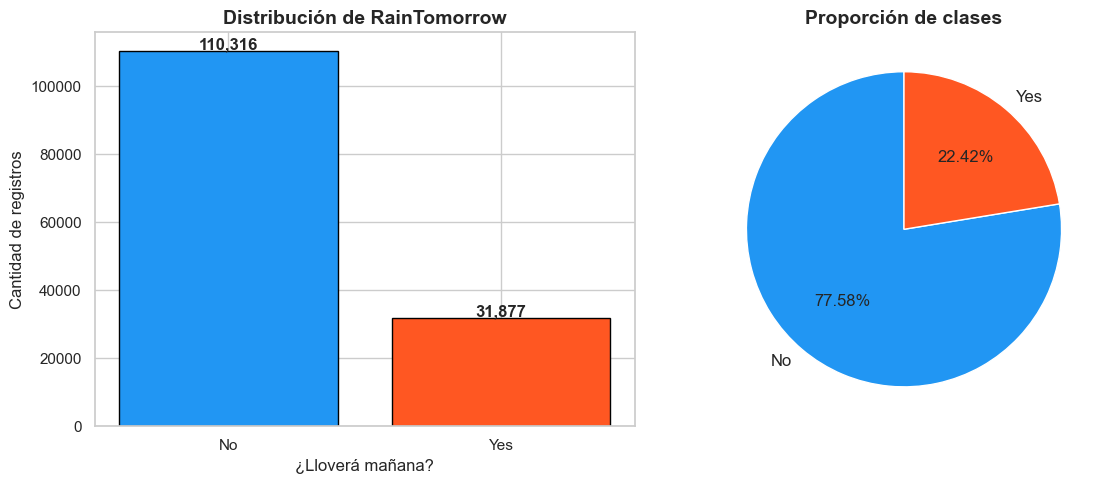

In [ ]:
# Distribución de la variable objetivo RainTomorrow
print("=" * 55)
print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: RainTomorrow")
print("=" * 55)

conteo = df["RainTomorrow"].value_counts()
porcentaje = df["RainTomorrow"].value_counts(normalize=True) * 100

resumen = pd.DataFrame({"Conteo": conteo, "Porcentaje (%)": porcentaje.round(2)})
print(resumen)

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
axes[0].bar(
    conteo.index, conteo.values, color=["#2196F3", "#FF5722"], edgecolor="black"
)
axes[0].set_title("Distribución de RainTomorrow", fontsize=14, fontweight="bold")
axes[0].set_xlabel("¿Lloverá mañana?")
axes[0].set_ylabel("Cantidad de registros")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")

# Gráfico de torta
axes[1].pie(
    conteo.values,
    labels=conteo.index,
    autopct="%1.2f%%",
    colors=["#2196F3", "#FF5722"],
    startangle=90,
    textprops={"fontsize": 12},
)
axes[1].set_title("Proporción de clases", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Aprendizaje Supervisado — Clasificación Binaria
- **Variable objetivo**: `RainTomorrow` (¿Lloverá mañana? -> Yes / No)
- **Tipo de problema**: Clasificación binaria
- **Algoritmos candidatos**: Árbol de Decisión, Random Forest, KNN, Regresión Logística

Como se observa en la distribución de la variable objetivo, existe un claro **desbalance de clases**:

| Clase | Registros | Porcentaje |
|---|---|---|
| **No** (no llueve) | 110.316 | 77,58% |
| **Yes** (llueve) | 31.877 | 22,42% |

Este desbalance es **esperable dado el contexto geográfico**: Australia es el continente más seco del planeta después de la Antártida, por lo que estadísticamente los días sin lluvia son ampliamente mayores. Sin embargo, desde el punto de vista del modelado, este desbalance representa un desafío importante ya que un modelo que prediga siempre "No" tendría una precisión aparente del **77,58%** sin haber aprendido nada útil. Este problema será abordado en la Fase 3 de preparación de datos.

### Aprendizaje No Supervisado — Clustering
- **Objetivo**: Identificar grupos de estaciones meteorológicas con comportamientos climáticos similares
- **Variables**: Temperatura, humedad, presión atmosférica, lluvia
- **Algoritmos candidatos**: K-Means, DBSCAN
- **Valor de negocio**: Segmentar el territorio australiano por patrones climáticos para apoyar políticas regionales de gestión del agua y prevención de desastres

## 1.5 Descripción del Dataset

In [ ]:
# Configuración de visualizaciones
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_theme(style="whitegrid")

# Carga del dataset
df = pd.read_csv("weatherAUS.csv")

# ── Inspección inicial ──────────────────────────────────────────
print("=" * 55)
print("DIMENSIONES DEL DATASET")
print("=" * 55)
print(f"  Registros   : {df.shape[0]:,}")
print(f"  Variables   : {df.shape[1]}")

print("\n" + "=" * 55)
print("RANGO TEMPORAL")
print("=" * 55)
df["Date"] = pd.to_datetime(df["Date"])
print(f"  Fecha mínima : {df['Date'].min().strftime('%d/%m/%Y')}")
print(f"  Fecha máxima : {df['Date'].max().strftime('%d/%m/%Y')}")
print(f"  Años cubiertos : {df['Date'].dt.year.nunique()}")

print("\n" + "=" * 55)
print("UBICACIONES")
print("=" * 55)
print(f"  Estaciones meteorológicas únicas : {df['Location'].nunique()}")
print(f"  Lista de ubicaciones:")
print(f"  {sorted(df['Location'].unique())}")

print("\n" + "=" * 55)
print("TIPOS DE VARIABLES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("PRIMERAS 5 FILAS")
print("=" * 55)
df.head()

DIMENSIONES DEL DATASET
  Registros   : 142,193
  Variables   : 24

RANGO TEMPORAL
  Fecha mínima : 01/11/2007
  Fecha máxima : 25/06/2017
  Años cubiertos : 11

UBICACIONES
  Estaciones meteorológicas únicas : 49
  Lista de ubicaciones:
  ['Adelaide', 'Albany', 'Albury', 'AliceSprings', 'BadgerysCreek', 'Ballarat', 'Bendigo', 'Brisbane', 'Cairns', 'Canberra', 'Cobar', 'CoffsHarbour', 'Dartmoor', 'Darwin', 'GoldCoast', 'Hobart', 'Katherine', 'Launceston', 'Melbourne', 'MelbourneAirport', 'Mildura', 'Moree', 'MountGambier', 'MountGinini', 'Newcastle', 'Nhil', 'NorahHead', 'NorfolkIsland', 'Nuriootpa', 'PearceRAAF', 'Penrith', 'Perth', 'PerthAirport', 'Portland', 'Richmond', 'Sale', 'SalmonGums', 'Sydney', 'SydneyAirport', 'Townsville', 'Tuggeranong', 'Uluru', 'WaggaWagga', 'Walpole', 'Watsonia', 'Williamtown', 'Witchcliffe', 'Wollongong', 'Woomera']

TIPOS DE VARIABLES
Date             datetime64[ns]
Location                 object
MinTemp                 float64
MaxTemp                

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


El conjunto de datos contiene observaciones meteorológicas diarias recopiladas por la **Oficina de Meteorología de la Commonwealth de Australia**, distribuidas en múltiples estaciones a lo largo del territorio nacional.

| Característica | Valor |
|---|---|
| **Total de registros** | 142.193 observaciones |
| **Total de variables** | 24 columnas |
| **Estaciones meteorológicas** | 49 ubicaciones distintas |
| **Período temporal** | 01/11/2007 — 25/06/2017 |
| **Años cubiertos** | 11 años de observaciones |
| **Variable objetivo** | `RainTomorrow` |
| **Variable de riesgo** | `RISK_MM` |

### Ubicaciones cubiertas
El dataset abarca **49 estaciones meteorológicas** distribuidas en los principales estados y territorios de Australia, incluyendo grandes ciudades como Sydney, Melbourne, Brisbane, Perth, Adelaide, Darwin y Hobart, además de zonas rurales e interiores como Uluru, AliceSprings y Cobar, lo que representa una amplia diversidad climática y geográfica del país.

### Tipos de Variables

| Tipo | Variables | Cantidad |
|---|---|---|
| **Numéricas continuas** | MinTemp, MaxTemp, Rainfall, Evaporation, Sunshine, WindGustSpeed, WindSpeed9am, WindSpeed3pm, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Cloud9am, Cloud3pm, Temp9am, Temp3pm, RISK_MM | 17 |
| **Categóricas** | Location, WindGustDir, WindDir9am, WindDir3pm, RainToday, RainTomorrow | 6 |
| **Temporal** | Date | 1 |

>**Nota sobre `RISK_MM`**: Esta variable representa la cantidad de lluvia registrada al día siguiente, por lo que constituye una **fuga de datos (*data leakage*)** si se utiliza como variable predictora. Será eliminada del conjunto de features durante la Fase 3.

### Criterios de Éxito del Negocio

| Criterio | ¿Por qué? | ¿Para qué? |
|---|---|---|
| **Predecir lluvia con alta precisión** | Australia enfrenta fenómenos climáticos extremos que impactan directamente en la economía y seguridad | Apoyar decisiones en agricultura, gestión hídrica y prevención de desastres |
| **Cobertura geográfica representativa** | El dataset cubre 49 estaciones en climas muy distintos, desde zonas desérticas hasta costeras | Garantizar que el modelo sea útil para distintas regiones del país y no solo para zonas húmedas |
| **Identificar variables climáticas clave** | No todas las variables tienen el mismo poder predictivo sobre la lluvia | Reducir costos operacionales enfocando los instrumentos de medición en las variables más relevantes |

### Criterios de Éxito del Modelo

| Criterio | ¿Por qué? | ¿Para qué? |
|---|---|---|
| **Dataset sin nulos ni outliers** | Los valores faltantes y atípicos distorsionan el aprendizaje del modelo generando predicciones incorrectas | Garantizar que el modelo generalice correctamente a nuevos datos sin overfitting ni underfitting |
| **Eliminar `RISK_MM`** | Esta variable contiene información del día siguiente, lo que constituye data leakage | Evitar que el modelo aprenda de información que no estaría disponible al momento de predecir |
| **Encoding de variables categóricas** | Los algoritmos matemáticos no pueden operar con texto como "Yes", "No" o "NNW" | Convertir estas variables a formato numérico para que el modelo pueda procesarlas |
| **Escalado de variables numéricas** | Variables como presión (~1010 hpa) y humedad (0–100%) están en escalas muy distintas | Evitar que el modelo asigne mayor importancia a variables solo por tener valores numéricamente más grandes |
| **Train/Test split estratificado** | El desbalance de clases (77,58% No / 22,42% Yes) puede concentrarse en un solo subconjunto | Garantizar que ambos conjuntos mantengan la misma proporción de clases para una evaluación confiable |

---
> *Con los objetivos, el problema y los criterios de éxito definidos, se procede a la Fase 2: Data Understanding, donde se explorará en profundidad la estructura, calidad y características del dataset.*

# FASE 2 — Data Understanding

##  2.1 Estadísticas Descriptivas

In [ ]:
# Estadísticas descriptivas de variables numéricas
print("=" * 55)
print("ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 55)

# Excluimos Date y RISK_MM (data leakage)
cols_numericas = df.select_dtypes(include=["float64"]).columns.tolist()
cols_numericas = [c for c in cols_numericas if c != "RISK_MM"]

desc = df[cols_numericas].describe().T
desc.columns = ["Conteo", "Media", "Std", "Mín", "Q1", "Mediana", "Q3", "Máx"]
desc = desc.round(2)
print(desc)

ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS
                 Conteo    Media    Std    Mín      Q1  Mediana      Q3  \
MinTemp        141556.0    12.19   6.40   -8.5     7.6     12.0    16.8   
MaxTemp        141871.0    23.23   7.12   -4.8    17.9     22.6    28.2   
Rainfall       140787.0     2.35   8.47    0.0     0.0      0.0     0.8   
Evaporation     81350.0     5.47   4.19    0.0     2.6      4.8     7.4   
Sunshine        74377.0     7.62   3.78    0.0     4.9      8.5    10.6   
WindGustSpeed  132923.0    39.98  13.59    6.0    31.0     39.0    48.0   
WindSpeed9am   140845.0    14.00   8.89    0.0     7.0     13.0    19.0   
WindSpeed3pm   139563.0    18.64   8.80    0.0    13.0     19.0    24.0   
Humidity9am    140419.0    68.84  19.05    0.0    57.0     70.0    83.0   
Humidity3pm    138583.0    51.48  20.80    0.0    37.0     52.0    66.0   
Pressure9am    128179.0  1017.65   7.11  980.5  1012.9   1017.6  1022.4   
Pressure3pm    128212.0  1015.26   7.04  977.1  1010

El dataset cuenta con **16 variables numéricas continuas** (excluyendo `RISK_MM` por data leakage). 
A continuación se destacan los hallazgos más relevantes:

### Temperaturas
| Variable | Media | Mín | Máx |
|---|---|---|---|
| `MinTemp` | 12,19°C | -8,5°C | 33,9°C |
| `MaxTemp` | 23,23°C | -4,8°C | 48,1°C |
| `Temp9am` | 16,99°C | -7,2°C | 40,2°C |
| `Temp3pm` | 21,69°C | -5,4°C | 46,7°C |

La temperatura máxima alcanza los **48,1°C**, consistente con el clima desértico del centro de Australia, mientras que las mínimas llegan a **-8,5°C** en zonas del sur y Tasmania, reflejando la gran diversidad climática del país.

### Lluvia y Evaporación
| Variable | Media | Mediana | Máx |
|---|---|---|---|
| `Rainfall` | 2,35 mm | 0,0 mm | 371,0 mm |
| `Evaporation` | 5,47 mm | 4,8 mm | 145,0 mm |
| `Sunshine` | 7,62 hrs | 8,5 hrs | 14,5 hrs |

La mediana de lluvia es **0,0 mm**, lo que confirma que la mayoría de los días en Australia no registra precipitaciones. Sin embargo, el máximo de **371,0 mm** en un solo día evidencia la presencia de eventos extremos como ciclones tropicales o lluvias monzónicas en el norte del país.

### Viento
| Variable | Media | Mín | Máx |
|---|---|---|---|
| `WindGustSpeed` | 39,98 km/hr | 6,0 km/hr | 135,0 km/hr |
| `WindSpeed9am` | 14,00 km/hr | 0,0 km/hr | 130,0 km/hr |
| `WindSpeed3pm` | 18,64 km/hr | 0,0 km/hr | 87,0 km/hr |

Las ráfagas máximas alcanzan los **135,0 km/hr**, valores asociados a vendavales y ciclones tropicales que Australia experimenta regularmente, especialmente en su costa norte y oeste.

### Humedad y Presión
| Variable | Media | Mín | Máx |
|---|---|---|---|
| `Humidity9am` | 68,84% | 0,0% | 100% |
| `Humidity3pm` | 51,48% | 0,0% | 100% |
| `Pressure9am` | 1017,65 hpa | 980,5 hpa | 1041,0 hpa |
| `Pressure3pm` | 1015,26 hpa | 977,1 hpa | 1039,6 hpa |

La humedad disminuye considerablemente entre las 9am y las 3pm, lo cual es esperable dado el aumento de temperatura durante el día. Los valores mínimos de **0%** de humedad y presiones de **977 hpa** sugieren la presencia de valores atípicos que serán analizados en detalle.

### Nubosidad
| Variable | Media | Mín | Máx |
|---|---|---|---|
| `Cloud9am` | 4,44 octavos | 0,0 | 9,0 |
| `Cloud3pm` | 4,50 octavos | 0,0 | 9,0 |

La escala de nubosidad va de **0 a 8 octavos**, por lo que el valor máximo de **9** representa un valor atípico a tratar en la Fase 3.

>**Insight**: La combinación de mediana de lluvia = 0, alta evaporación y temperaturas máximas extremas es coherente con el perfil climático árido de Australia, donde la lluvia es un evento relativamente infrecuente pero de alto impacto cuando ocurre.

## 2.2 Análisis de Valores Nulos

ANÁLISIS DE VALORES NULOS
               Nulos  Porcentaje (%)
Sunshine       67816           47.69
Evaporation    60843           42.79
Cloud3pm       57094           40.15
Cloud9am       53657           37.74
Pressure9am    14014            9.86
Pressure3pm    13981            9.83
WindDir9am     10013            7.04
WindGustDir     9330            6.56
WindGustSpeed   9270            6.52
WindDir3pm      3778            2.66
Humidity3pm     3610            2.54
Temp3pm         2726            1.92
WindSpeed3pm    2630            1.85
Humidity9am     1774            1.25
Rainfall        1406            0.99
RainToday       1406            0.99
WindSpeed9am    1348            0.95
Temp9am          904            0.64
MinTemp          637            0.45
MaxTemp          322            0.23


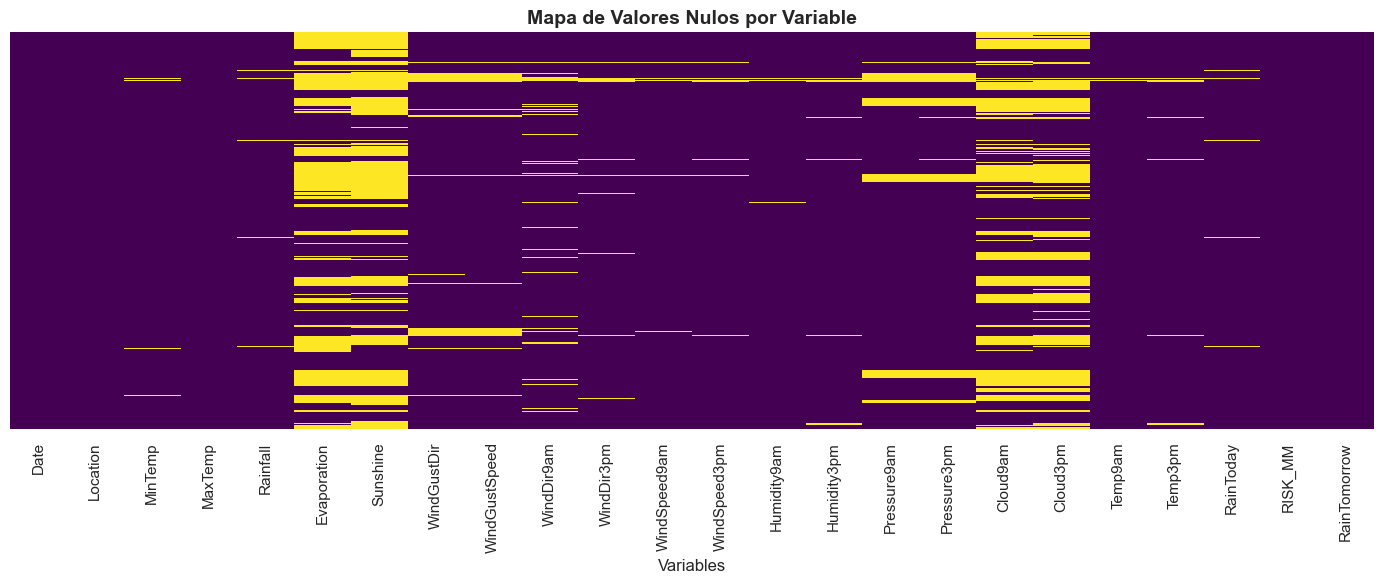

In [ ]:
# Análisis de valores nulos
print("=" * 55)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 55)

nulos = pd.DataFrame(
    {
        "Nulos": df.isnull().sum(),
        "Porcentaje (%)": (df.isnull().sum() / len(df) * 100).round(2),
    }
).sort_values("Porcentaje (%)", ascending=False)

nulos = nulos[nulos["Nulos"] > 0]
print(nulos)

# Heatmap de nulos
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Mapa de Valores Nulos por Variable", fontsize=14, fontweight="bold")
plt.xlabel("Variables")
plt.tight_layout()
plt.show()

Del total de 24 variables, **20 presentan valores nulos**, lo que representa un desafío 
significativo para el modelado. Se clasifican en tres grupos según su nivel de criticidad:

### Nulos Críticos (>30%) - Requieren procesamiento

| Variable | Nulos | Porcentaje |
|---|---|---|
| `Sunshine` | 67.816 | 47,69% |
| `Evaporation` | 60.843 | 42,79% |
| `Cloud3pm` | 57.094 | 40,15% |
| `Cloud9am` | 53.657 | 37,74% |

Estas 4 variables tienen entre un **37% y 48% de valores faltantes**, lo que indica que 
no todas las estaciones meteorológicas de Australia cuentan con instrumentos para medir 
horas de sol, evaporación o cobertura nubosa. Eliminar estas columnas o imputarlas 
requiere una justificación cuidadosa dada la **alta diversidad geográfica y climática** 
del país y su potencial impacto predictivo.

### Nulos Moderados (5% — 15%)

| Variable | Nulos | Porcentaje |
|---|---|---|
| `Pressure9am` | 14.014 | 9,86% |
| `Pressure3pm` | 13.981 | 9,83% |
| `WindDir9am` | 10.013 | 7,04% |
| `WindGustDir` | 9.330 | 6,56% |
| `WindGustSpeed` | 9.270 | 6,52% |

La presión atmosférica y las variables de viento presentan un porcentaje moderado de 
nulos, probablemente asociado a fallas en los instrumentos de medición o condiciones 
climáticas extremas que impidieron el registro.

### Nulos Bajos (<5%) - Imputación directa

| Variable | Nulos | Porcentaje |
|---|---|---|
| `WindDir3pm` | 3.778 | 2,66% |
| `Humidity3pm` | 3.610 | 2,54% |
| `Temp3pm` | 2.726 | 1,92% |
| `WindSpeed3pm` | 2.630 | 1,85% |
| `Humidity9am` | 1.774 | 1,25% |
| `Rainfall` | 1.406 | 0,99% |
| `RainToday` | 1.406 | 0,99% |
| `WindSpeed9am` | 1.348 | 0,95% |
| `Temp9am` | 904 | 0,64% |
| `MinTemp` | 637 | 0,45% |
| `MaxTemp` | 322 | 0,23% |

Estas variables presentan menos del 5% de nulos y pueden ser tratadas con técnicas 
estándar de imputación sin riesgo de introducir sesgos significativos.

> **Nota**: Las variables `Date` y `Location` no presentan valores nulos, 
> lo que garantiza la trazabilidad temporal y geográfica de cada observación. 
> El tratamiento específico de cada grupo será abordado en la **Fase 3 — Data Preparation**.

## 2.3 Distribución de Variables Numéricas

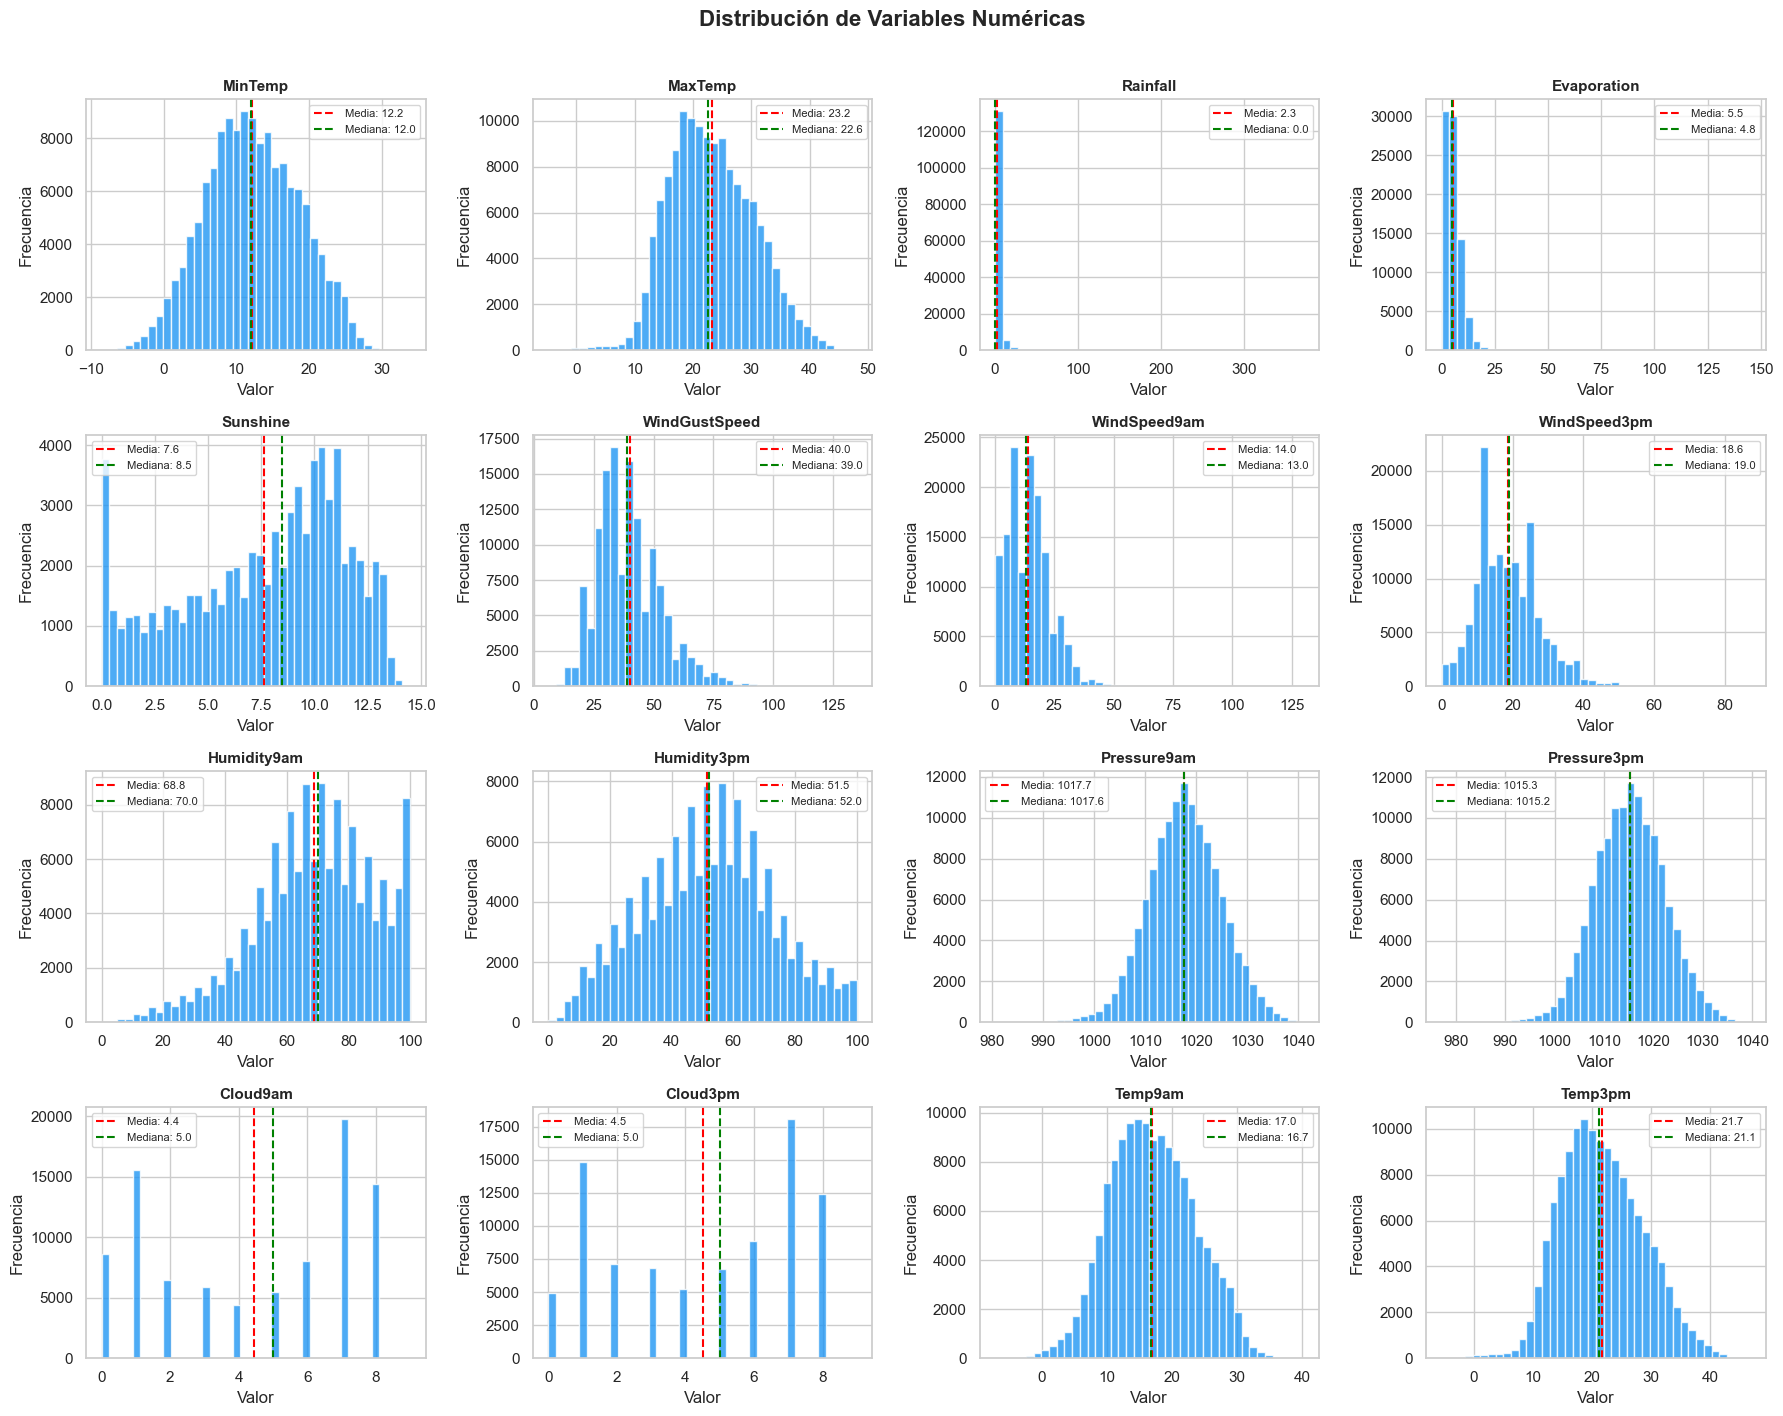

In [8]:
# Distribución de variables numéricas
cols_numericas = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Pressure3pm",
    "Cloud9am",
    "Cloud3pm",
    "Temp9am",
    "Temp3pm",
]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    axes[i].hist(
        df[col].dropna(), bins=40, color="#2196F3", edgecolor="white", alpha=0.8
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")
    axes[i].axvline(
        df[col].mean(),
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Media: {df[col].mean():.1f}",
    )
    axes[i].axvline(
        df[col].median(),
        color="green",
        linestyle="--",
        linewidth=1.5,
        label=f"Mediana: {df[col].median():.1f}",
    )
    axes[i].legend(fontsize=8)

plt.suptitle(
    "Distribución de Variables Numéricas", fontsize=16, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

### Temperaturas — Distribución Normal
`MinTemp`, `MaxTemp`, `Temp9am` y `Temp3pm` presentan distribuciones 
aproximadamente **normales y simétricas**, con media y mediana muy cercanas 
(Media MinTemp: 12,2°C / Mediana: 12,0°C). Esto indica que las temperaturas 
en Australia se distribuyen de forma homogénea alrededor de su valor central, 
sin grandes distorsiones por valores extremos.

### Lluvia y Evaporación — Distribución Sesgada a la Derecha
`Rainfall` y `Evaporation` presentan una fuerte **asimetría positiva (sesgo a la derecha)**:
- `Rainfall`: Media 2,3 mm vs Mediana 0,0 mm — la mayoría de los días no registra lluvia, 
pero existen eventos extremos que elevan la media considerablemente
- `Evaporation`: Media 5,5 mm vs Mediana 4,8 mm — distribución concentrada en valores bajos 
con cola extendida hacia valores altos

Este comportamiento es consistente con el perfil climático árido de Australia, donde 
la lluvia es un evento infrecuente pero de alta magnitud cuando ocurre.

### Viento — Distribución Sesgada a la Derecha
`WindGustSpeed`, `WindSpeed9am` y `WindSpeed3pm` presentan **sesgo positivo**, 
con la mayoría de los registros concentrados en velocidades bajas-moderadas y 
una cola hacia velocidades extremas (ráfagas de hasta 135 km/hr), asociadas 
a eventos climáticos severos como ciclones y vendavales.

### Humedad — Distribución Bimodal
`Humidity9am` y `Humidity3pm` presentan un comportamiento **bimodal**, con 
concentraciones tanto en valores bajos (zonas áridas del interior) como en 
valores altos (zonas costeras húmedas). Esto refleja la coexistencia de 
climas muy distintos dentro del mismo dataset.

### Presión Atmosférica — Distribución Normal
`Pressure9am` y `Pressure3pm` presentan distribuciones **normales y simétricas** 
concentradas alrededor de 1017 hpa y 1015 hpa respectivamente, con valores 
extremos bajos (~980 hpa) que podrían estar asociados a sistemas de baja presión 
intensa como ciclones tropicales.

### Nubosidad — Distribución Discreta
`Cloud9am` y `Cloud3pm` presentan una distribución **discreta en escala de octavos (0-8)**, 
con picos en los extremos (0 = cielo despejado y 8 = cielo totalmente cubierto), 
lo que sugiere que los días tienden a ser claramente despejados o claramente nublados, 
con pocos estados intermedios. El valor 9 observado en las estadísticas descriptivas 
confirma la presencia de valores atípicos fuera del rango válido.

> **Insight**: Las distribuciones sesgadas en `Rainfall`, `Evaporation` y variables 
> de viento anticipan la necesidad de tratamiento de outliers en la Fase 3, ya que 
> estos valores extremos pueden distorsionar el aprendizaje de los modelos.

## 2.4 Análisis de Outliers

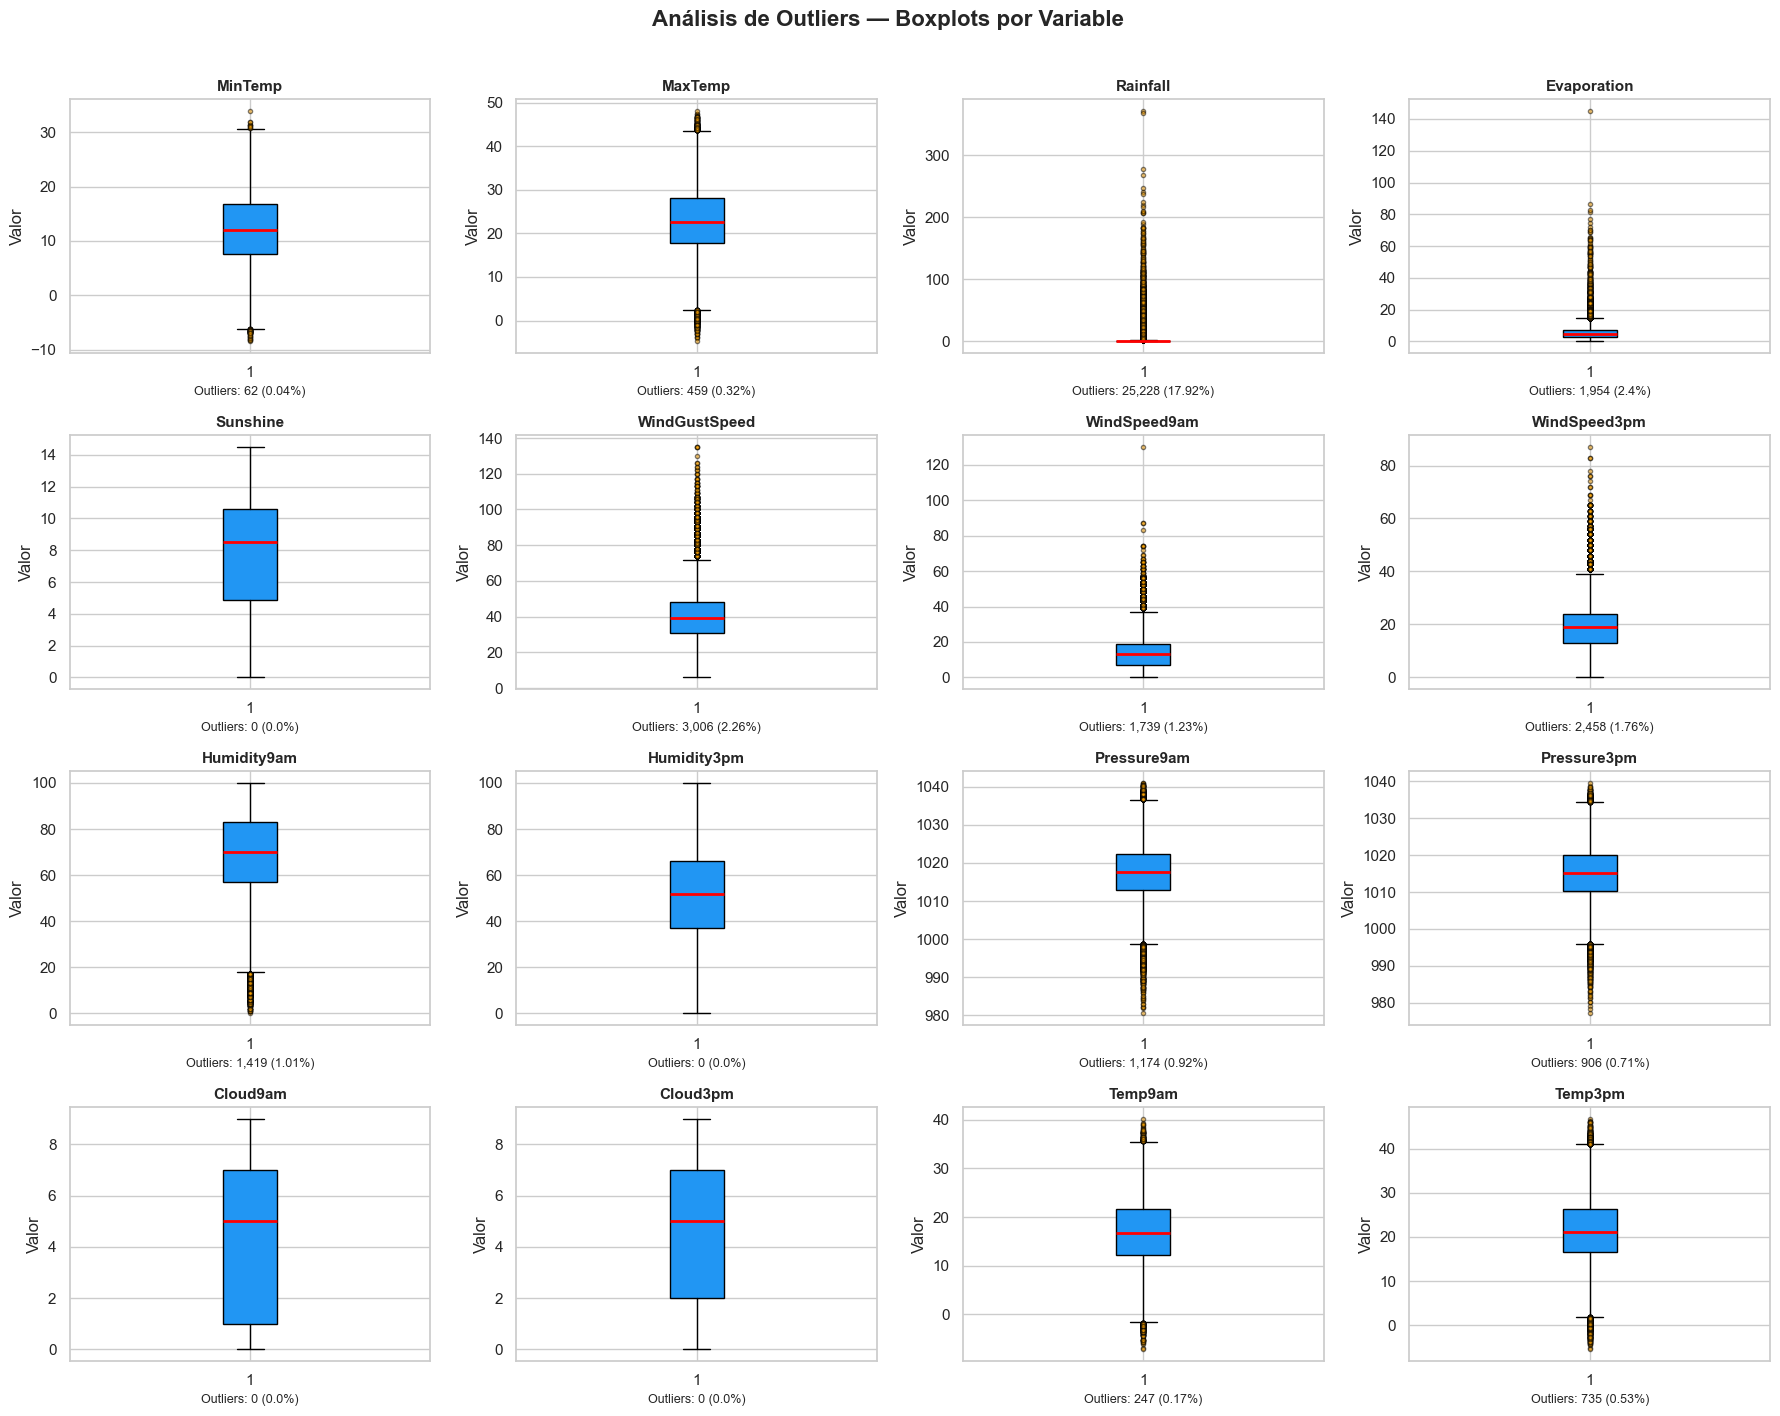

RESUMEN DE OUTLIERS POR VARIABLE (MÉTODO IQR)
                   Q1      Q3   IQR  Límite Inferior  Límite Superior  \
Variable                                                                
MinTemp           7.6    16.8   9.2            -6.20            30.60   
MaxTemp          17.9    28.2  10.3             2.45            43.65   
Rainfall          0.0     0.8   0.8            -1.20             2.00   
Evaporation       2.6     7.4   4.8            -4.60            14.60   
Sunshine          4.9    10.6   5.7            -3.65            19.15   
WindGustSpeed    31.0    48.0  17.0             5.50            73.50   
WindSpeed9am      7.0    19.0  12.0           -11.00            37.00   
WindSpeed3pm     13.0    24.0  11.0            -3.50            40.50   
Humidity9am      57.0    83.0  26.0            18.00           122.00   
Humidity3pm      37.0    66.0  29.0            -6.50           109.50   
Pressure9am    1012.9  1022.4   9.5           998.65          1036.65   
Press

In [11]:
# Análisis de outliers mediante boxplots
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#2196F3", color="black"),
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="orange", markersize=3, alpha=0.5),
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Valor")

    # Calcular outliers con IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    pct = round(len(outliers) / df[col].dropna().shape[0] * 100, 2)
    axes[i].set_xlabel(f"Outliers: {len(outliers):,} ({pct}%)", fontsize=9)

plt.suptitle(
    "Análisis de Outliers — Boxplots por Variable",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

# Tabla resumen de outliers
print("=" * 55)
print("RESUMEN DE OUTLIERS POR VARIABLE (MÉTODO IQR)")
print("=" * 55)
resumen_outliers = []
for col in cols_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col]
    pct = round(len(outliers) / df[col].dropna().shape[0] * 100, 2)
    resumen_outliers.append(
        {
            "Variable": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": round(IQR, 2),
            "Límite Inferior": round(Q1 - 1.5 * IQR, 2),
            "Límite Superior": round(Q3 + 1.5 * IQR, 2),
            "N° Outliers": len(outliers),
            "Porcentaje (%)": pct,
        }
    )

resumen_df = pd.DataFrame(resumen_outliers).set_index("Variable")
print(resumen_df)

Se aplicó el **método IQR (Rango Intercuartílico)** para detectar valores atípicos, 
definiendo como outlier todo valor que se encuentre fuera del rango 
**[Q1 - 1.5×IQR, Q3 + 1.5×IQR]**. Este es el método estándar de la industria 
para detección de outliers en variables continuas.

### Outliers Críticos (>5%)

| Variable | N° Outliers | Porcentaje | Límite Superior |
|---|---|---|---|
| `Rainfall` | 25.228 | 17,92% | 2,0 mm |

`Rainfall` es la variable con mayor presencia de outliers con un **17,92%** de sus 
registros fuera del rango IQR. Esto no necesariamente representa errores de medición, 
sino eventos de lluvia intensa reales como ciclones tropicales y lluvias monzónicas, 
característicos del norte de Australia. Cualquier registro superior a **2,0 mm** es 
clasificado como outlier por este método, lo que evidencia que en Australia la lluvia 
es un fenómeno extremo por naturaleza.

### Outliers Moderados (1% — 5%)

| Variable | N° Outliers | Porcentaje |
|---|---|---|
| `Evaporation` | 1.954 | 2,40% |
| `WindGustSpeed` | 3.006 | 2,26% |
| `WindSpeed3pm` | 2.458 | 1,76% |
| `WindSpeed9am` | 1.739 | 1,23% |
| `Humidity9am` | 1.419 | 1,01% |

Las variables de viento presentan outliers asociados a eventos climáticos extremos 
como vendavales y ciclones. La evaporación alta se registra en zonas desérticas del 
centro del país durante el verano, donde las temperaturas superan los 40°C.

### Outliers Bajos (<1%)

| Variable | N° Outliers | Porcentaje |
|---|---|---|
| `MaxTemp` | 459 | 0,32% |
| `Temp3pm` | 735 | 0,53% |
| `Temp9am` | 247 | 0,17% |
| `Pressure9am` | 1.174 | 0,92% |
| `Pressure3pm` | 906 | 0,71% |
| `MinTemp` | 62 | 0,04% |

### Sin Outliers
`Sunshine`, `Humidity3pm`, `Cloud9am` y `Cloud3pm` no presentan outliers 
según el método IQR, lo que indica que sus valores se distribuyen de forma 
homogénea dentro del rango esperado.

> **Nota importante**: La ausencia de outliers en `Cloud9am` y `Cloud3pm` 
> según IQR no descarta los valores **9** detectados en las estadísticas descriptivas, 
> ya que la escala válida es de 0 a 8 octavos. Estos valores serán tratados 
> como errores de registro en la Fase 3.

> **Insight**: Los outliers en variables de lluvia y viento no son necesariamente 
> errores de medición sino **fenómenos climáticos reales** propios de Australia. 
> Su tratamiento debe ser cuidadoso para no eliminar información valiosa sobre 
> eventos extremos que son precisamente los más relevantes para el negocio.

## 2.5 Matriz de Correlación

MATRIZ DE CORRELACIÓN — VARIABLES NUMÉRICAS

Correlación de variables con RainTomorrow:
RainTomorrow     1.00
Humidity3pm      0.45
Cloud3pm         0.38
Cloud9am         0.32
Humidity9am      0.26
Rainfall         0.24
WindGustSpeed    0.23
WindSpeed3pm     0.09
WindSpeed9am     0.09
MinTemp          0.08
Temp9am         -0.03
Evaporation     -0.12
MaxTemp         -0.16
Temp3pm         -0.19
Pressure3pm     -0.23
Pressure9am     -0.25
Sunshine        -0.45
Name: RainTomorrow, dtype: float64


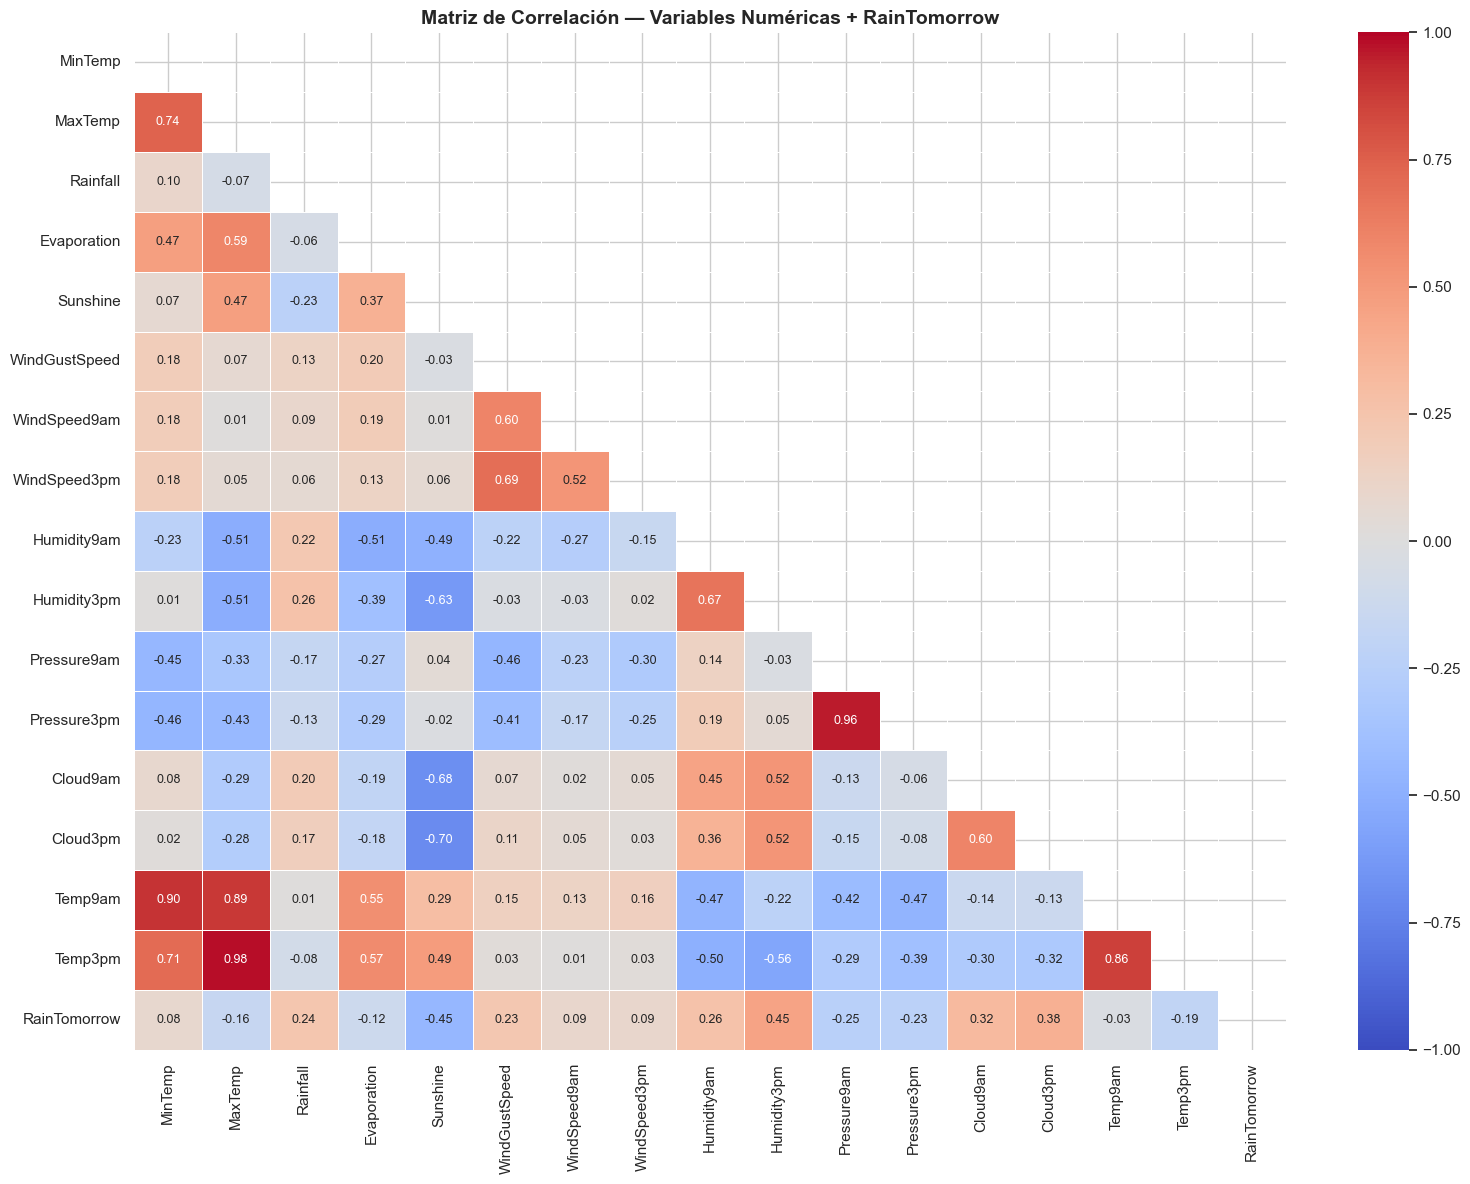

In [12]:
# Matriz de correlación
print("=" * 55)
print("MATRIZ DE CORRELACIÓN — VARIABLES NUMÉRICAS")
print("=" * 55)

# Codificación temporal de RainTomorrow para incluirla en correlación
df_corr = df[cols_numericas].copy()
df_corr["RainTomorrow"] = df["RainTomorrow"].map({"Yes": 1, "No": 0})

corr_matrix = df_corr.corr().round(2)

# Correlaciones con RainTomorrow ordenadas
print("\nCorrelación de variables con RainTomorrow:")
print(corr_matrix["RainTomorrow"].sort_values(ascending=False))

# Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 9},
)
plt.title(
    "Matriz de Correlación — Variables Numéricas + RainTomorrow",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

### Correlaciones con la Variable Objetivo `RainTomorrow`

| Variable        | Correlación | Dirección | Interpretación                                                          |
| --------------- | ----------- | --------- | ----------------------------------------------------------------------- |
| `Humidity3pm`   | 0,45        | Positiva  | A mayor humedad a las 3pm, mayor probabilidad de lluvia mañana          |
| `Cloud3pm`      | 0,38        | Positiva  | Mayor cobertura nubosa a las 3pm aumenta la probabilidad de lluvia      |
| `Cloud9am`      | 0,32        | Positiva  | Mayor cobertura nubosa en la mañana también es predictor relevante      |
| `Humidity9am`   | 0,26        | Positiva  | La humedad matutina también se correlaciona con lluvia al día siguiente |
| `Rainfall`      | 0,24        | Positiva  | Si llovió hoy, es más probable que llueva mañana                        |
| `WindGustSpeed` | 0,23        | Positiva  | Vientos más fuertes se asocian a mayor probabilidad de lluvia           |
| `Sunshine`      | -0,45       | Negativa  | Más horas de sol reducen significativamente la probabilidad de lluvia   |
| `Pressure9am`   | -0,25       | Negativa  | Mayor presión atmosférica se asocia a días despejados sin lluvia        |
| `Pressure3pm`   | -0,23       | Negativa  | Confirmación del efecto de la presión sobre la lluvia                   |
| `Temp3pm`       | -0,19       | Negativa  | Temperaturas más altas en la tarde se asocian a menor lluvia            |
| `MaxTemp`       | -0,16       | Negativa  | Días más calurosos tienden a ser más secos                              |

> **Insight de alto impacto**: Las variables más predictivas de lluvia son
> `Humidity3pm` (0,45) y `Sunshine` (-0,45), ambas con igual magnitud pero
> dirección opuesta. Un día húmedo y nublado a las 3pm es el mejor predictor
> de lluvia al día siguiente, mientras que un día soleado es el mejor predictor
> de que no lloverá.


### Correlaciones entre Variables Predictoras

| Par de Variables                | Correlación | Alerta                        |
| ------------------------------- | ----------- | ----------------------------- |
| `Pressure9am` — `Pressure3pm`   | 0,96        | Multicolinealidad alta     |
| `Temp9am` — `MinTemp`           | 0,90        | Multicolinealidad alta     |
| `Temp3pm` — `MaxTemp`           | 0,98        | Multicolinealidad alta     |
| `Temp9am` — `Temp3pm`           | 0,86        | Multicolinealidad alta     |
| `WindSpeed9am` — `WindSpeed3pm` | 0,52        | Correlación moderada       |
| `Sunshine` — `Cloud3pm`         | -0,70       | Correlación inversa fuerte |
| `Sunshine` — `Cloud9am`         | -0,68       | Correlación inversa fuerte |

La presencia de **multicolinealidad alta** entre variables de temperatura
(`Temp3pm` — `MaxTemp`: 0,98) y presión (`Pressure9am` — `Pressure3pm`: 0,96)
indica que estas variables contienen información redundante. En modelos sensibles
a la multicolinealidad como la Regresión Logística, será necesario considerar
la eliminación de una de cada par para evitar inestabilidad en los coeficientes.

## 2.6 Análisis de Lluvia por Ubicación

ANÁLISIS DE LLUVIA POR UBICACIÓN
       Ubicación  Días con Lluvia Mañana (%)
        Portland                       36.55
         Walpole                       33.66
          Cairns                       31.79
        Dartmoor                       31.33
   NorfolkIsland                       31.01
    MountGambier                       30.36
          Albany                       29.91
     Witchcliffe                       29.78
    CoffsHarbour                       29.43
     MountGinini                       28.17
       NorahHead                       27.59
     Williamtown                       27.42
          Darwin                       26.69
       Melbourne                       26.12
       GoldCoast                       26.01
          Sydney                       25.92
        Ballarat                       25.79
   SydneyAirport                       25.76
       Newcastle                       24.74
        Watsonia                       24.61
      Wollongong      

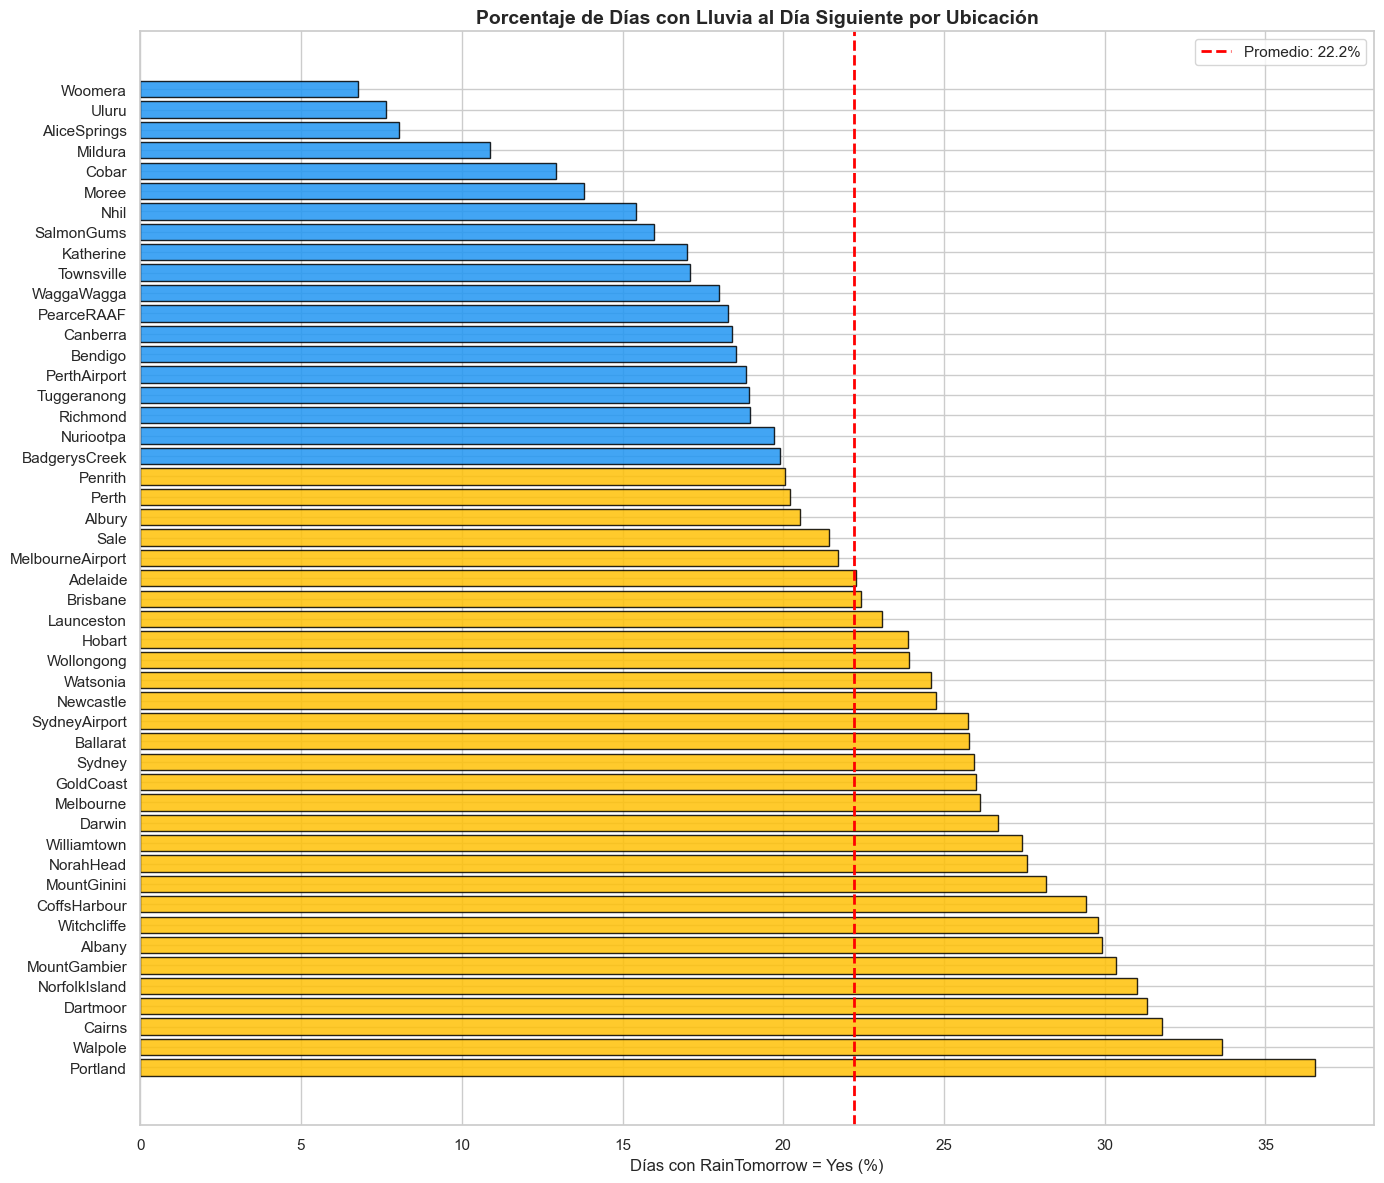


LLUVIA PROMEDIO (mm) POR UBICACIÓN — TOP 10
Location
Cairns          5.77
Darwin          5.09
CoffsHarbour    5.05
GoldCoast       3.73
Wollongong      3.59
Williamtown     3.51
Townsville      3.49
NorahHead       3.38
Sydney          3.33
MountGinini     3.25
Name: Rainfall, dtype: float64


In [13]:
# Análisis de lluvia por ubicación geográfica
print("=" * 55)
print("ANÁLISIS DE LLUVIA POR UBICACIÓN")
print("=" * 55)

# Porcentaje de días con lluvia mañana por ubicación
lluvia_ubicacion = (
    df.groupby("Location")["RainTomorrow"]
    .apply(lambda x: (x == "Yes").sum() / len(x) * 100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
lluvia_ubicacion.columns = ["Ubicación", "Días con Lluvia Mañana (%)"]
print(lluvia_ubicacion.to_string(index=False))

# Gráfico de barras horizontal
plt.figure(figsize=(14, 12))
colors = [
    "#FF5722" if x > 40 else "#2196F3" if x < 20 else "#FFC107"
    for x in lluvia_ubicacion["Días con Lluvia Mañana (%)"]
]
plt.barh(
    lluvia_ubicacion["Ubicación"],
    lluvia_ubicacion["Días con Lluvia Mañana (%)"],
    color=colors,
    edgecolor="black",
    alpha=0.85,
)
plt.axvline(
    x=lluvia_ubicacion["Días con Lluvia Mañana (%)"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Promedio: {lluvia_ubicacion["Días con Lluvia Mañana (%)"].mean():.1f}%',
)
plt.title(
    "Porcentaje de Días con Lluvia al Día Siguiente por Ubicación",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Días con RainTomorrow = Yes (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Lluvia promedio por ubicación
print("\n" + "=" * 55)
print("LLUVIA PROMEDIO (mm) POR UBICACIÓN — TOP 10")
print("=" * 55)
lluvia_mm = (
    df.groupby("Location")["Rainfall"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .head(10)
)
print(lluvia_mm)

### Distribución Geográfica de la Lluvia

El análisis por ubicación revela una **marcada heterogeneidad geográfica** en los 
patrones de lluvia, consistente con la diversidad climática de Australia descrita 
en la Fase 1.

### Ubicaciones con Mayor Probabilidad de Lluvia (>25%)

| Ubicación | Días con Lluvia (%) | Región |
|---|---|---|
| `Portland` | 36,55% | Victoria — Costa sur |
| `Walpole` | 33,66% | Western Australia — Costa suroeste |
| `Cairns` | 31,79% | Queensland — Trópico norte |
| `Dartmoor` | 31,33% | Victoria — Costa sur |
| `NorfolkIsland` | 31,01% | Territorio insular — Océano Pacífico |
| `MountGambier` | 30,36% | South Australia — Costa sur |
| `Albany` | 29,91% | Western Australia — Costa sur |
| `CoffsHarbour` | 29,43% | New South Wales — Costa este |

Estas ubicaciones corresponden principalmente a **zonas costeras del sur y este**, 
donde el clima templado con lluvias moderadas todo el año es predominante, 
y al **norte tropical** donde las lluvias monzónicas son frecuentes en verano.

### Ubicaciones con Menor Probabilidad de Lluvia (<15%)

| Ubicación | Días con Lluvia (%) | Región |
|---|---|---|
| `Woomera` | 6,76% | South Australia — Interior desértico |
| `Uluru` | 7,63% | Northern Territory — Centro desértico |
| `AliceSprings` | 8,05% | Northern Territory — Centro desértico |
| `Mildura` | 10,87% | Victoria — Interior semiárido |
| `Cobar` | 12,92% | New South Wales — Interior árido |

Estas ubicaciones se encuentran en el **interior desértico y semiárido** de Australia, 
donde la lluvia es un evento extremadamente infrecuente. Woomera registra lluvia 
al día siguiente solo el **6,76%** de los días, menos de 1 día de cada 15.

### Lluvia Promedio por Ubicación — Top 10

| Ubicación | Lluvia Promedio (mm) | Característica |
|---|---|---|
| `Cairns` | 5,77 mm | Ciudad tropical, lluvias monzónicas |
| `Darwin` | 5,09 mm | Capital del NT, clima tropical |
| `CoffsHarbour` | 5,05 mm | Costa este, lluvias todo el año |
| `GoldCoast` | 3,73 mm | Costa subtropical Queensland |
| `Wollongong` | 3,59 mm | Costa sur NSW |

> **Insight de alto impacto**: Existe una clara **brecha geográfica** entre las 
> zonas costeras húmedas (Portland: 36,55%, Walpole: 33,66%) y el interior desértico 
> (Woomera: 6,76%, Uluru: 7,63%). Esta diferencia de casi **30 puntos porcentuales** 
> confirma que la ubicación geográfica es una variable crítica para la predicción 
> de lluvia y que un modelo entrenado sin considerar la ubicación podría generalizar 
> pobremente entre regiones climáticamente opuestas.

> **Insight de alto impacto**: `Cairns` y `Darwin`, ubicadas en el norte tropical, 
> lideran tanto en frecuencia de lluvia como en volumen promedio por evento (5,77 mm 
> y 5,09 mm respectivamente), lo que refleja el régimen monzónico del norte australiano 
> donde la lluvia es intensa y concentrada en la estación húmeda.

# Fase 3 — Data Preparation

## 3.1 Eliminación de columnas irrelevantes o ruidosas


In [ ]:
# Paso 0: Eliminación de variable con data leakage
print(f"\nDimensiones antes de eliminación : {df.shape}")

# Eliminar RISK_MM
df.drop(columns=["RISK_MM"], inplace=True)

print(f"Dimensiones después de eliminación: {df.shape}")
print(f"\nColumnas actuales:")
print(df.columns.tolist())

PASO 0: ELIMINACIÓN DE RISK_MM

Dimensiones antes de eliminación : (142193, 24)
Dimensiones después de eliminación: (142193, 23)

Columnas actuales:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']


In [ ]:
# 1. Varianza de variables numéricas
print("\n1. VARIANZA DE VARIABLES NUMÉRICAS")
print("-" * 55)
cols_num = df.select_dtypes(include=["float64"]).columns.tolist()
varianza = df[cols_num].var().round(4).sort_values()
print(varianza)

# 2. Cardinalidad de variables categóricas
print("\n2. CARDINALIDAD DE VARIABLES CATEGÓRICAS")
print("-" * 55)
cols_cat = df.select_dtypes(include=["object"]).columns.tolist()
for col in cols_cat:
    print(f"  {col:15} : {df[col].nunique()} valores únicos -> {df[col].unique()[:5]}")

# 3. Correlaciones altas entre variables numéricas (redundancia)
print("\n3. PARES CON CORRELACIÓN > 0.85 (REDUNDANCIA)")
print("-" * 55)
corr = df[cols_num].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pares_altos = [
    (col, row, round(upper.loc[row, col], 2))
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > 0.85
]
for par in pares_altos:
    print(f"  {par[0]:15} — {par[1]:15} : {par[2]}")

ANÁLISIS DE RUIDO ESTRUCTURAL Y REDUNDANCIA

1. VARIANZA DE VARIABLES NUMÉRICAS
-------------------------------------------------------
Cloud3pm           7.4018
Cloud9am           8.3349
Sunshine          14.2999
Evaporation       17.5438
MinTemp           41.0020
Temp9am           42.1569
Temp3pm           48.1302
Pressure3pm       49.5148
Pressure9am       50.4878
MaxTemp           50.6605
Rainfall          71.6592
WindSpeed3pm      77.4989
WindSpeed9am      79.0914
WindGustSpeed    184.6555
Humidity9am      362.9517
Humidity3pm      432.5473
dtype: float64

2. CARDINALIDAD DE VARIABLES CATEGÓRICAS
-------------------------------------------------------
  Location        : 49 valores únicos -> ['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree']
  WindGustDir     : 16 valores únicos -> ['W' 'WNW' 'WSW' 'NE' 'NNW']
  WindDir9am      : 16 valores únicos -> ['W' 'NNW' 'SE' 'ENE' 'SW']
  WindDir3pm      : 16 valores únicos -> ['WNW' 'WSW' 'E' 'NW' 'W']
  RainToday       : 2 valores

In [ ]:
print(f"\nDimensiones antes de eliminación : {df.shape}")

# Eliminar variables redundantes
vars_redundantes = ["Temp3pm", "Temp9am", "Pressure3pm"]
df.drop(columns=vars_redundantes, inplace=True)

print(f"Dimensiones después de eliminación: {df.shape}")
print(f"\nVariables eliminadas:")
for v in vars_redundantes:
    print(f"  {v}")

print(f"\nColumnas restantes:")
print(df.columns.tolist())

PASO 0.1: ELIMINACIÓN DE VARIABLES REDUNDANTES

Dimensiones antes de eliminación : (142193, 23)
Dimensiones después de eliminación: (142193, 20)

Variables eliminadas:
  Temp3pm
  Temp9am
  Pressure3pm

Columnas restantes:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Cloud9am', 'Cloud3pm', 'RainToday', 'RainTomorrow']


Antes de cualquier transformación, se eliminan las variables que contaminarían
el modelo con información que no estaría disponible al momento de predecir.

| Variable  | Acción       | Razón                                                                                                                                     |
| --------- | ------------ | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `RISK_MM` | Eliminada | Contiene la cantidad de lluvia registrada al día siguiente, lo que constituye **data leakage** — el modelo estaría aprendiendo del futuro |

El dataset pasa de **24 a 23 columnas**, manteniendo los **142.193 registros** intactos.

> **¿Por qué es crítico eliminar `RISK_MM`?** Un modelo entrenado con esta variable
> alcanzaría una precisión artificialmente alta durante el entrenamiento, pero fallaría
> completamente en producción donde esta información no existe al momento de predecir.
> Esto es uno de los errores más graves en proyectos de Machine Learning.


Se eliminaron variables con **correlación superior a 0,85** con otras variables
del dataset, ya que aportan información redundante que puede generar
multicolinealidad y afectar la estabilidad de los modelos.

| Variable Eliminada | Variable que la Reemplaza | Correlación | Justificación                                                                     |
| ------------------ | ------------------------- | ----------- | --------------------------------------------------------------------------------- |
| `Temp3pm`          | `MaxTemp`                 | 0,98        | La temperatura máxima del día captura equivalentemente la temperatura de la tarde |
| `Temp9am`          | `MinTemp` + `MaxTemp`     | 0,90 / 0,89 | La temperatura matutina queda representada por el rango min-max del día           |
| `Pressure3pm`      | `Pressure9am`             | 0,96        | La presión atmosférica matutina es suficiente para representar el estado del día  |

El dataset pasa de **23 a 20 columnas**, manteniendo los **142.193 registros** intactos.

> **¿Por qué es importante eliminar variables redundantes?** La multicolinealidad
> entre variables predictoras puede inflar artificialmente la importancia de ciertas
> variables, generar inestabilidad en los coeficientes de modelos lineales y aumentar
> innecesariamente la complejidad computacional del modelo sin agregar valor predictivo.


## 3.2 Extracción de Mes y Estación desde Date

In [ ]:
# Extraer mes
df["Mes"] = df["Date"].dt.month


# Definir estaciones según calendario australiano
# Verano: Dic-Feb (12,1,2), Otoño: Mar-May (3,4,5)
# Invierno: Jun-Ago (6,7,8), Primavera: Sep-Nov (9,10,11)
def asignar_estacion(mes):
    if mes in [12, 1, 2]:
        return "Verano"
    elif mes in [3, 4, 5]:
        return "Otono"
    elif mes in [6, 7, 8]:
        return "Invierno"
    else:
        return "Primavera"


df["Estacion"] = df["Mes"].apply(asignar_estacion)

# Eliminar Date
df.drop(columns=["Date"], inplace=True)

print(f"\nDimensiones después de transformación: {df.shape}")

print("\nDistribución de registros por Mes:")
print(df["Mes"].value_counts().sort_index())

print("\nDistribución de registros por Estación:")
print(df["Estacion"].value_counts())

print("\nLluvia mañana por Estación (%):")
lluvia_estacion = (
    df.groupby("Estacion")["RainTomorrow"]
    .apply(lambda x: round((x == "Yes").sum() / len(x) * 100, 2))
    .sort_values(ascending=False)
)
print(lluvia_estacion)

PASO 1: EXTRACCIÓN DE MES Y ESTACIÓN DESDE DATE

Dimensiones después de transformación: (142193, 21)

Distribución de registros por Mes:
Mes
1     12921
2     10525
3     13036
4     11306
5     13055
6     12389
7     11779
8     11762
9     11345
10    11804
11    11461
12    10810
Name: count, dtype: int64

Distribución de registros por Estación:
Estacion
Otono        37397
Invierno     35930
Primavera    34610
Verano       34256
Name: count, dtype: int64

Lluvia mañana por Estación (%):
Estacion
Invierno     26.12
Otono        21.89
Primavera    21.24
Verano       20.30
Name: RainTomorrow, dtype: float64


La variable `Date` no puede ser utilizada directamente por modelos matemáticos, 
sin embargo contiene información estacional valiosa. Se extrajeron dos nuevas 
variables y luego se eliminó `Date` del dataset.

### Variables creadas

| Variable | Tipo | Valores | Descripción |
|---|---|---|---|
| `Mes` | Numérica (1-12) | 1 a 12 | Mes de la observación |
| `Estacion` | Categórica | Verano, Otoño, Invierno, Primavera | Estación del año según calendario australiano |

### Calendario Estacional Australiano
| Estación | Meses | Registros |
|---|---|---|
| Verano | Diciembre, Enero, Febrero | 34.256 |
| Otoño | Marzo, Abril, Mayo | 37.397 |
| Invierno | Junio, Julio, Agosto | 35.930 |
| Primavera | Septiembre, Octubre, Noviembre | 34.610 |

### Probabilidad de Lluvia por Estación

| Estación | Días con Lluvia Mañana (%) |
|---|---|
| **Invierno** | 26,12% |
| **Otoño** | 21,89% |
| **Primavera** | 21,24% |
| **Verano** | 20,30% |

El **invierno** presenta la mayor probabilidad de lluvia con un **26,12%**, 
casi 6 puntos porcentuales por encima del verano (20,30%). Esto es consistente 
con el clima templado del sur y sureste de Australia, donde las lluvias frontales 
son más frecuentes en invierno. El verano presenta menor probabilidad de lluvia 
a nivel nacional, aunque en el norte tropical concentra las lluvias monzónicas 
más intensas del año.

El dataset pasa de **20 a 21 columnas** tras eliminar `Date` y agregar `Mes` y `Estacion`.

> **Insight**: La estacionalidad tiene impacto directo en la probabilidad de lluvia. 
> Incorporar `Mes` y `Estacion` como variables permite al modelo capturar patrones 
> temporales sin depender de una fecha específica que no tendría valor predictivo directo.

## 3.3 Corrección de Valores Inválidos en Nubosidad

In [ ]:
# Verificar valores fuera del rango válido (0-8 octavos)
print("\nValores únicos Cloud9am:", sorted(df["Cloud9am"].dropna().unique()))
print("Valores únicos Cloud3pm:", sorted(df["Cloud3pm"].dropna().unique()))

print("\nRegistros con valor 9 antes de corrección:")
print(f"  Cloud9am : {(df['Cloud9am'] == 9).sum()}")
print(f"  Cloud3pm : {(df['Cloud3pm'] == 9).sum()}")

# Reemplazar valor 9 por NaN
df["Cloud9am"] = df["Cloud9am"].replace(9, np.nan)
df["Cloud3pm"] = df["Cloud3pm"].replace(9, np.nan)

print("\nRegistros con valor 9 después de corrección:")
print(f"  Cloud9am : {(df['Cloud9am'] == 9).sum()}")
print(f"  Cloud3pm : {(df['Cloud3pm'] == 9).sum()}")

print("\nNulos actualizados:")
print(
    f"  Cloud9am : {df['Cloud9am'].isnull().sum()} ({df['Cloud9am'].isnull().sum()/len(df)*100:.2f}%)"
)
print(
    f"  Cloud3pm : {df['Cloud3pm'].isnull().sum()} ({df['Cloud3pm'].isnull().sum()/len(df)*100:.2f}%)"
)

PASO 2: CORRECCIÓN DE VALORES INVÁLIDOS EN NUBOSIDAD

Valores únicos Cloud9am: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]
Valores únicos Cloud3pm: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0)]

Registros con valor 9 antes de corrección:
  Cloud9am : 2
  Cloud3pm : 1

Registros con valor 9 después de corrección:
  Cloud9am : 0
  Cloud3pm : 0

Nulos actualizados:
  Cloud9am : 53659 (37.74%)
  Cloud3pm : 57095 (40.15%)


Las variables `Cloud9am` y `Cloud3pm` miden la cobertura nubosa en **octavos (0-8)**,
donde 0 representa cielo completamente despejado y 8 cielo completamente cubierto.
Se detectaron registros con valor **9**, que está fuera del rango válido de la escala
y corresponde a un error de registro.

| Variable   | Registros con valor 9 | Acción                 |
| ---------- | --------------------- | ---------------------- |
| `Cloud9am` | 2                     | Reemplazados por `NaN` |
| `Cloud3pm` | 1                     | Reemplazados por `NaN` |

Si bien la cantidad de registros inválidos es pequeña (3 en total), su corrección
es necesaria ya que un valor fuera de escala distorsionaría el aprendizaje del modelo,
asignando importancia a un estado de nubosidad inexistente.


### Nulos actualizados tras corrección

| Variable   | Nulos  | Porcentaje |
| ---------- | ------ | ---------- |
| `Cloud9am` | 53.659 | 37,74%     |
| `Cloud3pm` | 57.095 | 40,15%     |

> Estos nulos serán tratados en el siguiente paso mediante imputación por mediana,
> dado que a pesar de su alto porcentaje, ambas variables mostraron correlaciones
> relevantes con `RainTomorrow` (`Cloud9am`: 0,32 y `Cloud3pm`: 0,38) en la Fase 2.

## 3.4 Tratamiento de Nulos en Variables Numéricas

In [ ]:
cols_num = df.select_dtypes(include=["float64"]).columns.tolist()

# Nulos antes de imputación
print("\nNulos antes de imputación:")
nulos_antes = df[cols_num].isnull().sum()
nulos_antes_pct = (df[cols_num].isnull().sum() / len(df) * 100).round(2)
resumen_antes = pd.DataFrame(
    {
        "Nulos": nulos_antes,
        "Porcentaje (%)": nulos_antes_pct,
    }
).sort_values("Nulos", ascending=False)
resumen_antes = resumen_antes[resumen_antes["Nulos"] > 0]
print(resumen_antes)

# Imputación por mediana
medianas = df[cols_num].median()
for col in cols_num:
    df[col].fillna(medianas[col], inplace=True)

# Verificación
print("\nNulos después de imputación:")
nulos_despues = df[cols_num].isnull().sum().sum()
print(f"  Total nulos en variables numéricas: {nulos_despues}")

print("\nMedianas utilizadas para imputación:")
print(medianas.round(2))

PASO 3: TRATAMIENTO DE NULOS — VARIABLES NUMÉRICAS

Nulos antes de imputación:
               Nulos  Porcentaje (%)
Sunshine       67816           47.69
Evaporation    60843           42.79
Cloud3pm       57095           40.15
Cloud9am       53659           37.74
Pressure9am    14014            9.86
WindGustSpeed   9270            6.52
Humidity3pm     3610            2.54
WindSpeed3pm    2630            1.85
Humidity9am     1774            1.25
Rainfall        1406            0.99
WindSpeed9am    1348            0.95
MinTemp          637            0.45
MaxTemp          322            0.23

Nulos después de imputación:
  Total nulos en variables numéricas: 0

Medianas utilizadas para imputación:
MinTemp            12.0
MaxTemp            22.6
Rainfall            0.0
Evaporation         4.8
Sunshine            8.5
WindGustSpeed      39.0
WindSpeed9am       13.0
WindSpeed3pm       19.0
Humidity9am        70.0
Humidity3pm        52.0
Pressure9am      1017.6
Cloud9am            5.0
Cloud3p

Se aplicó **imputación por mediana** a todas las variables numéricas con valores 
faltantes. La mediana es preferida sobre la media en este caso porque:

- El dataset presenta variables con **distribuciones sesgadas** (`Rainfall`, `Evaporation`)
  donde la media es arrastrada por valores extremos
- La mediana es **robusta frente a outliers**, preservando mejor el valor central real

### Nulos tratados por variable

| Variable | Nulos | Porcentaje | Mediana Imputada |
|---|---|---|---|
| `Sunshine` | 67.816 | 47,69% | 8,5 hrs |
| `Evaporation` | 60.843 | 42,79% | 4,8 mm |
| `Cloud3pm` | 57.095 | 40,15% | 5,0 octavos |
| `Cloud9am` | 53.659 | 37,74% | 5,0 octavos |
| `Pressure9am` | 14.014 | 9,86% | 1017,6 hpa |
| `WindGustSpeed` | 9.270 | 6,52% | 39,0 km/hr |
| `Humidity3pm` | 3.610 | 2,54% | 52,0% |
| `WindSpeed3pm` | 2.630 | 1,85% | 19,0 km/hr |
| `Humidity9am` | 1.774 | 1,25% | 70,0% |
| `Rainfall` | 1.406 | 0,99% | 0,0 mm |
| `WindSpeed9am` | 1.348 | 0,95% | 13,0 km/hr |
| `MinTemp` | 637 | 0,45% | 12,0°C |
| `MaxTemp` | 322 | 0,23% | 22,6°C |

Tras la imputación el total de nulos en variables numéricas es **0**.

> **Decisión sobre variables con alto porcentaje de nulos**: `Sunshine` (47,69%), 
> `Evaporation` (42,79%), `Cloud3pm` (40,15%) y `Cloud9am` (37,74%) fueron imputadas 
> en lugar de eliminadas debido a su relevancia predictiva identificada en la Fase 2. 
> `Sunshine` presentó la correlación negativa más alta con `RainTomorrow` (-0,45), 
> equivalente en magnitud a `Humidity3pm` (0,45), la variable más predictiva positiva. 
> Eliminarla hubiera significado perder el predictor más importante de días sin lluvia.

## 3.5 Tratamiento de Nulos en Variables Categóricas

In [20]:
cols_cat = df.select_dtypes(include=["object"]).columns.tolist()

# Nulos antes de imputación
print("\nNulos antes de imputación:")
nulos_cat = df[cols_cat].isnull().sum()
nulos_cat_pct = (df[cols_cat].isnull().sum() / len(df) * 100).round(2)
resumen_cat = pd.DataFrame(
    {
        "Nulos": nulos_cat,
        "Porcentaje (%)": nulos_cat_pct,
        "Moda": [df[col].mode()[0] for col in cols_cat],
    }
).sort_values("Nulos", ascending=False)
resumen_cat = resumen_cat[resumen_cat["Nulos"] > 0]
print(resumen_cat)

# Imputación por moda
for col in cols_cat:
    moda = df[col].mode()[0]
    df[col].fillna(moda, inplace=True)

# Verificación
print("\nNulos después de imputación:")
nulos_despues = df[cols_cat].isnull().sum().sum()
print(f"  Total nulos en variables categóricas: {nulos_despues}")


Nulos antes de imputación:
             Nulos  Porcentaje (%) Moda
WindDir9am   10013            7.04    N
WindGustDir   9330            6.56    W
WindDir3pm    3778            2.66   SE
RainToday     1406            0.99   No

Nulos después de imputación:
  Total nulos en variables categóricas: 0


Se aplicó **imputación por moda** a todas las variables categóricas con valores
faltantes. La moda es la única estrategia de imputación válida para variables
nominales, ya que no existe un orden numérico que permita calcular media o mediana.


### Nulos tratados por variable

| Variable      | Nulos  | Porcentaje | Moda Imputada | Interpretación                              |
| ------------- | ------ | ---------- | ------------- | ------------------------------------------- |
| `WindDir9am`  | 10.013 | 7,04%      | N (Norte)     | Dirección de viento más frecuente a las 9am |
| `WindGustDir` | 9.330  | 6,56%      | W (Oeste)     | Dirección de ráfaga más frecuente en 24 hrs |
| `WindDir3pm`  | 3.778  | 2,66%      | SE (Sureste)  | Dirección de viento más frecuente a las 3pm |
| `RainToday`   | 1.406  | 0,99%      | No            | La mayoría de los días no registra lluvia   |

Tras la imputación el total de nulos en variables categóricas es **0**.

> **Limitación de la imputación por moda**: Al imputar direcciones de viento
> con la moda global, se asume que la dirección más frecuente en todo el dataset
> es representativa para cualquier ubicación y época del año. Sin embargo, la
> dirección del viento varía significativamente entre regiones (vientos del oeste
> en el sur, vientos del norte en zonas tropicales). Esta limitación es aceptable
> dado el bajo porcentaje de nulos, pero debe considerarse al interpretar los
> resultados del modelo.

## 3.6 Tratamiento de Outliers

               Límite Inferior  Límite Superior  Outliers Antes  \
Variable                                                          
MinTemp                  -6.20            30.60              62   
MaxTemp                   2.45            43.65             459   
Rainfall                 -0.90             1.50           28545   
Evaporation               1.90             7.50           32317   
Sunshine                  7.45             9.45           60823   
WindGustSpeed             8.50            68.50            5386   
WindSpeed9am            -11.00            37.00            1739   
WindSpeed3pm             -3.50            40.50            2458   
Humidity9am              18.00           122.00            1419   
Humidity3pm              -5.00           107.00               0   
Pressure9am            1001.05          1034.25            2708   
Cloud9am                 -1.50            10.50               0   
Cloud3pm                  1.00             9.00            495

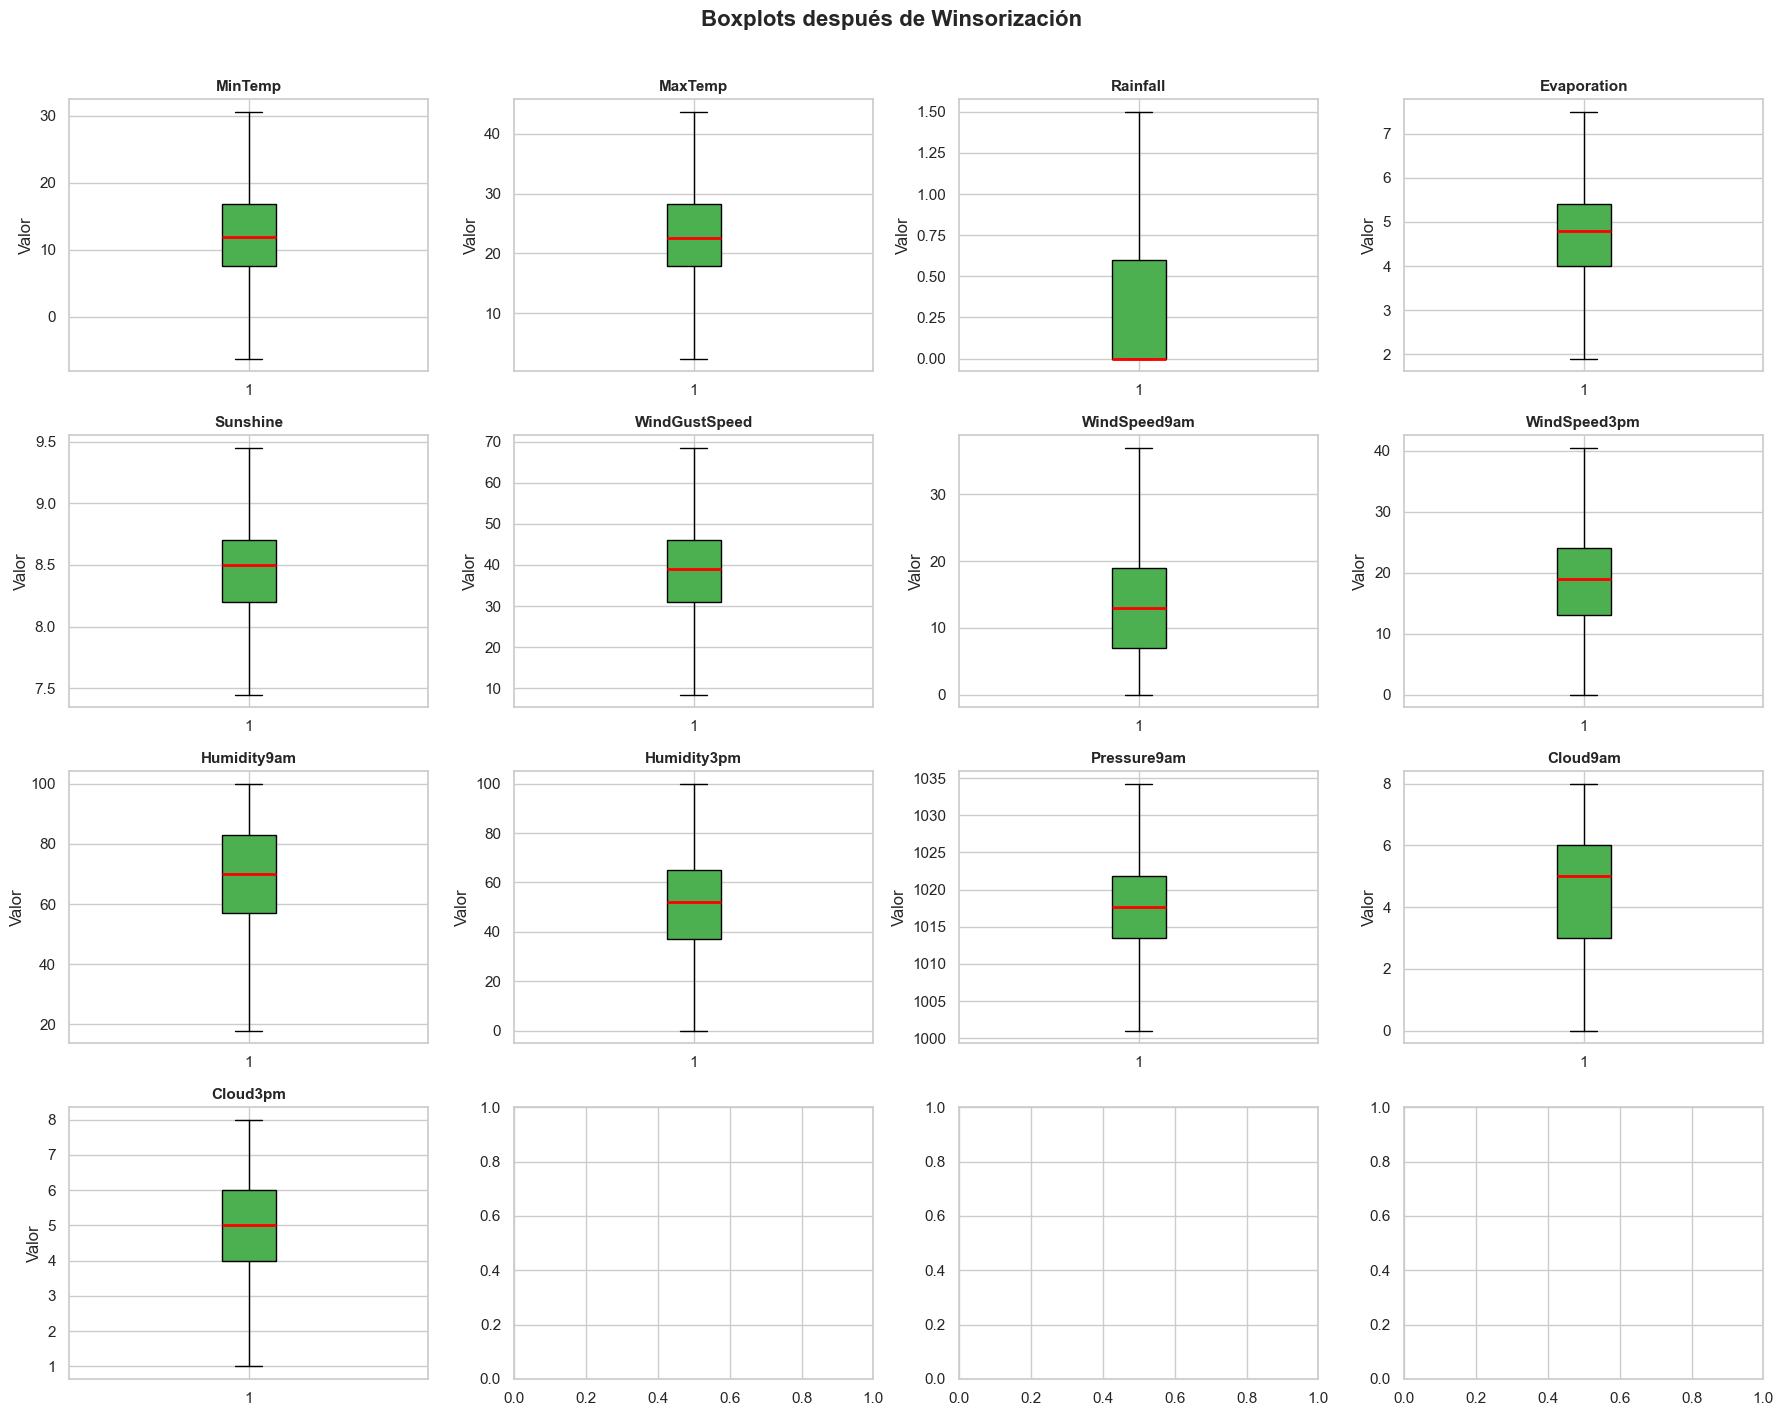

In [21]:
cols_num = df.select_dtypes(include=["float64"]).columns.tolist()

resumen_wins = []
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers_antes = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()

    # Winsorización
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

    outliers_despues = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()

    resumen_wins.append(
        {
            "Variable": col,
            "Límite Inferior": round(lim_inf, 2),
            "Límite Superior": round(lim_sup, 2),
            "Outliers Antes": outliers_antes,
            "Outliers Después": outliers_despues,
        }
    )

resumen_wins_df = pd.DataFrame(resumen_wins).set_index("Variable")
print(resumen_wins_df)

# Boxplots después de winsorización
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    axes[i].boxplot(
        df[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="#4CAF50", color="black"),
        medianprops=dict(color="red", linewidth=2),
        flierprops=dict(marker="o", markerfacecolor="orange", markersize=3, alpha=0.5),
    )
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Valor")

plt.suptitle(
    "Boxplots después de Winsorización", fontsize=16, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

Se aplicó **Winsorización** como técnica de tratamiento de outliers, reemplazando
los valores extremos por los límites del rango IQR en lugar de eliminar los registros.
Esto preserva los **142.193 registros** del dataset sin pérdida de información.

> **¿Por qué Winsorización y no eliminación?** Eliminar filas con outliers en un
> dataset meteorológico significaría perder precisamente los eventos climáticos
> extremos (lluvias intensas, vientos fuertes) que son los más relevantes para
> el negocio. La Winsorización mantiene estos registros acotando sus valores
> al rango válido definido por el método IQR.

### Resultados por Variable

| Variable        | Límite Inferior | Límite Superior | Outliers Antes | Outliers Después |
| --------------- | --------------- | --------------- | -------------- | ---------------- |
| `Rainfall`      | -0,90           | 1,50            | 28.545         | 0                |
| `Evaporation`   | 1,90            | 7,50            | 32.317         | 0                |
| `Sunshine`      | 7,45            | 9,45            | 60.823         | 0                |
| `Pressure9am`   | 1001,05         | 1034,25         | 2.708          | 0                |
| `Cloud3pm`      | 1,00            | 9,00            | 4.957          | 0                |
| `WindGustSpeed` | 8,50            | 68,50           | 5.386          | 0                |
| `WindSpeed3pm`  | -3,50           | 40,50           | 2.458          | 0                |
| `WindSpeed9am`  | -11,00          | 37,00           | 1.739          | 0                |
| `Humidity9am`   | 18,00           | 122,00          | 1.419          | 0                |
| `MaxTemp`       | 2,45            | 43,65           | 459            | 0                |
| `MinTemp`       | -6,20           | 30,60           | 62             | 0                |
| `Humidity3pm`   | -5,00           | 107,00          | 0              | 0                |
| `Cloud9am`      | -1,50           | 10,50           | 0              | 0                |

Tras la Winsorización el total de outliers en todas las variables numéricas es **0**.

### Observaciones relevantes

- **`Sunshine`** presentó **60.823 outliers** antes de la Winsorización, el valor más
  alto de todas las variables. Esto se explica porque el método IQR definió un rango
  muy estrecho (7,45 — 9,45 hrs), lo que refleja que la mayoría de los días registran
  entre 7,5 y 9,5 horas de sol, siendo los días con muy pocas o muchas horas de sol
  estadísticamente atípicos.

- **`Rainfall`** presentó **28.545 outliers**, confirmando que cualquier registro
  superior a **1,5 mm** es considerado atípico en el contexto australiano, donde la
  mediana de lluvia diaria es 0,0 mm.

- **`Evaporation`** presentó **32.317 outliers**, asociados a eventos de alta
  evaporación en zonas desérticas durante el verano australiano.

> **Insight**: Los boxplots post-Winsorización muestran distribuciones
> considerablemente más compactas y sin valores extremos, lo que garantiza que
> los modelos matemáticos no serán influenciados desproporcionadamente por
> eventos climáticos excepcionales durante el entrenamiento.

## 3.7 Encoding de Variables Categóricas

In [22]:
print(f"\nDimensiones antes del encoding: {df.shape}")

# 1. Label Encoding para variables binarias
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# RainToday y RainTomorrow: Yes=1, No=0
df["RainToday"] = le.fit_transform(df["RainToday"])
df["RainTomorrow"] = le.fit_transform(df["RainTomorrow"])

print("\n1. Label Encoding aplicado:")
print(
    f"  RainToday    : No=0, Yes=1 -> Valores únicos: {sorted(df['RainToday'].unique())}"
)
print(
    f"  RainTomorrow : No=0, Yes=1 -> Valores únicos: {sorted(df['RainTomorrow'].unique())}"
)

# 2. One Hot Encoding para variables nominales
cols_ohe = ["WindGustDir", "WindDir9am", "WindDir3pm", "Location", "Estacion"]
df = pd.get_dummies(df, columns=cols_ohe, drop_first=False)

print(f"\n2. One Hot Encoding aplicado a: {cols_ohe}")
print(f"\nDimensiones después del encoding: {df.shape}")

# Verificar nuevas columnas
nuevas_cols = [
    c for c in df.columns if any(c.startswith(col + "_") for col in cols_ohe)
]
print(f"\nNuevas columnas generadas: {len(nuevas_cols)}")
for col in cols_ohe:
    cols_gen = [c for c in df.columns if c.startswith(col + "_")]
    print(f"  {col}: {len(cols_gen)} columnas")


Dimensiones antes del encoding: (142193, 21)

1. Label Encoding aplicado:
  RainToday    : No=0, Yes=1 -> Valores únicos: [np.int64(0), np.int64(1)]
  RainTomorrow : No=0, Yes=1 -> Valores únicos: [np.int64(0), np.int64(1)]

2. One Hot Encoding aplicado a: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'Location', 'Estacion']

Dimensiones después del encoding: (142193, 117)

Nuevas columnas generadas: 101
  WindGustDir: 16 columnas
  WindDir9am: 16 columnas
  WindDir3pm: 16 columnas
  Location: 49 columnas
  Estacion: 4 columnas


Los algoritmos de Machine Learning operan exclusivamente con valores numéricos,
por lo que las variables categóricas deben ser transformadas antes del modelado.
Se aplicaron dos técnicas según el tipo de variable:


### 1. Label Encoding — Variables Binarias

Aplicado a variables con exactamente dos categorías, asignando 0 y 1:

| Variable       | Antes    | Después |
| -------------- | -------- | ------- |
| `RainToday`    | No / Yes | 0 / 1   |
| `RainTomorrow` | No / Yes | 0 / 1   |


### 2. One Hot Encoding — Variables Nominales

Aplicado a variables con más de dos categorías sin orden jerárquico,
generando una columna binaria por cada categoría:

| Variable      | Categorías     | Columnas Generadas |
| ------------- | -------------- | ------------------ |
| `WindGustDir` | 16 direcciones | 16 columnas        |
| `WindDir9am`  | 16 direcciones | 16 columnas        |
| `WindDir3pm`  | 16 direcciones | 16 columnas        |
| `Location`    | 49 ubicaciones | 49 columnas        |
| `Estacion`    | 4 estaciones   | 4 columnas         |


### Resultado del Encoding

|                               | Antes         | Después        |
| ----------------------------- | ------------- | -------------- |
| **Dimensiones**               | (142.193, 21) | (142.193, 117) |
| **Variables originales**      | 21            | —              |
| **Nuevas columnas generadas** | —             | 101            |
| **Total columnas**            | 21            | 117            |

> **¿Por qué One Hot Encoding y no Label Encoding para direcciones y ubicaciones?**
> Las direcciones de viento (N, S, E, W, NNW, etc.) y las ubicaciones no tienen
> un orden numérico natural. Aplicar Label Encoding les asignaría un orden artificial
> (ej. N=0, NNE=1, NE=2) que el modelo interpretaría como jerarquía cuando no existe.
> One Hot Encoding evita este sesgo creando variables binarias independientes.

> **Nota sobre `drop_first=False`**: Se mantienen todas las categorías para
> preservar la interpretabilidad del modelo y evitar pérdida de información,
> asumiendo que los modelos a utilizar pueden manejar la multicolinealidad resultante.


## 3.8 Escalado de variables numéricas

In [24]:
# Identificar columnas numéricas originales (excluir OHE y target)
cols_escalar = [
    "MinTemp",
    "MaxTemp",
    "Rainfall",
    "Evaporation",
    "Sunshine",
    "WindGustSpeed",
    "WindSpeed9am",
    "WindSpeed3pm",
    "Humidity9am",
    "Humidity3pm",
    "Pressure9am",
    "Cloud9am",
    "Cloud3pm",
    "Mes",
    "RainToday",
]

print(f"\nVariables a escalar: {cols_escalar}")

# Estadísticas antes del escalado
print("\nEstadísticas antes del escalado:")
print(df[cols_escalar].describe().T[["mean", "std", "min", "max"]].round(2))

# Aplicar StandardScaler
scaler = StandardScaler()
df[cols_escalar] = scaler.fit_transform(df[cols_escalar])

# Estadísticas después del escalado
print("\nEstadísticas después del escalado:")
print(df[cols_escalar].describe().T[["mean", "std", "min", "max"]].round(2))


Variables a escalar: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Cloud9am', 'Cloud3pm', 'Mes', 'RainToday']

Estadísticas antes del escalado:
                  mean    std      min      max
MinTemp          12.19   6.39    -6.20    30.60
MaxTemp          23.23   7.09     2.45    43.65
Rainfall          0.39   0.61     0.00     1.50
Evaporation       4.80   1.63     1.90     7.50
Sunshine          8.47   0.68     7.45     9.45
WindGustSpeed    39.60  12.20     8.50    68.50
WindSpeed9am     13.90   8.55     0.00    37.00
WindSpeed3pm     18.56   8.45     0.00    40.50
Humidity9am      68.91  18.78    18.00   100.00
Humidity3pm      51.50  20.53     0.00   100.00
Pressure9am    1017.68   6.59  1001.05  1034.25
Cloud9am          4.65   2.29     0.00     8.00
Cloud3pm          4.74   2.05     1.00     8.00
Mes               6.40   3.43     1.00    12.00
RainToday         0.22  

Se aplicó **StandardScaler** a las variables numéricas, transformando cada variable
para que tenga **media = 0** y **desviación estándar = 1**. La fórmula aplicada es:

$$z = \frac{x - \mu}{\sigma}$$

Donde $x$ es el valor original, $\mu$ la media y $\sigma$ la desviación estándar.



### ¿Por qué es necesario escalar?

Sin escalado, variables como `Pressure9am` (rango: 1001 — 1034 hpa) dominarían
sobre variables como `RainToday` (rango: 0 — 1) simplemente por tener valores
numéricamente más grandes, sin que esto refleje mayor importancia predictiva.

### Resultado del Escalado

| Variable        | Media Antes | Media Después | Std Antes | Std Después |
| --------------- | ----------- | ------------- | --------- | ----------- |
| `MinTemp`       | 12,19       | 0,0           | 6,39      | 1,0         |
| `MaxTemp`       | 23,23       | 0,0           | 7,09      | 1,0         |
| `Pressure9am`   | 1017,68     | 0,0           | 6,59      | 1,0         |
| `Humidity9am`   | 68,91       | 0,0           | 18,78     | 1,0         |
| `Humidity3pm`   | 51,50       | 0,0           | 20,53     | 1,0         |
| `WindGustSpeed` | 39,60       | 0,0           | 12,20     | 1,0         |
| `Rainfall`      | 0,39        | 0,0           | 0,61      | 1,0         |
| `Sunshine`      | 8,47        | 0,0           | 0,68      | 1,0         |
| `Mes`           | 6,40        | 0,0           | 3,43      | 1,0         |
| `RainToday`     | 0,22        | 0,0           | 0,42      | 1,0         |

Todas las variables quedan con **media = 0** y **desviación estándar = 1**,
eliminando las diferencias de escala entre variables.

> **Variables excluidas del escalado**: Las columnas generadas por One Hot
> Encoding (`WindGustDir_*`, `WindDir9am_*`, `WindDir3pm_*`, `Location_*`,
> `Estacion_*`) y la variable objetivo `RainTomorrow` no fueron escaladas,
> ya que son variables binarias (0/1) que ya se encuentran en la misma escala.

> **¿Por qué StandardScaler y no MinMaxScaler?** StandardScaler es más
> robusto frente a outliers residuales y es el estándar de la industria para
> modelos como SVM, KNN y Regresión Logística. MinMaxScaler es más sensible
> a valores extremos ya que depende del mínimo y máximo de cada variable.


## 3.9 Train/Test split estratificado


Dimensiones del dataset completo:
  X (features)  : (142193, 116)
  y (target)    : (142193,)

Dimensiones tras el split:
  X_train : (113754, 116)
  X_test  : (28439, 116)
  y_train : (113754,)
  y_test  : (28439,)

Balance de clases — Dataset completo:
  No (0): 110,316 (77.58%)
  Yes(1): 31,877 (22.42%)

Balance de clases — Train:
  No (0): 88,252 (77.58%)
  Yes(1): 25,502 (22.42%)

Balance de clases — Test:
  No (0): 22,064 (77.58%)
  Yes(1): 6,375 (22.42%)


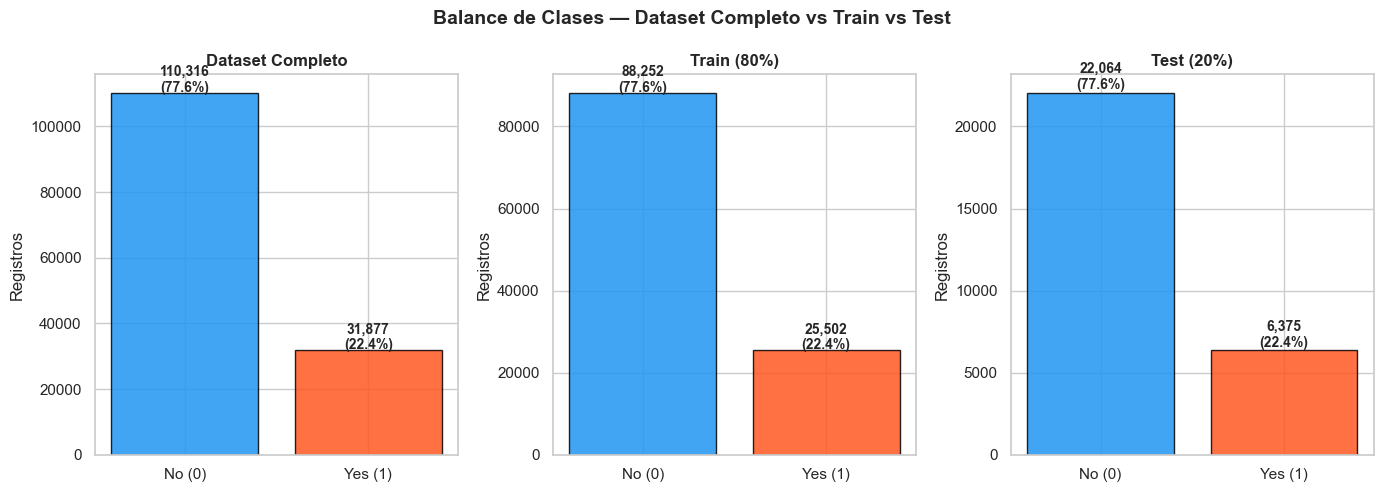

In [26]:
# Separar features y variable objetivo
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

print(f"\nDimensiones del dataset completo:")
print(f"  X (features)  : {X.shape}")
print(f"  y (target)    : {y.shape}")

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDimensiones tras el split:")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}")
print(f"  y_test  : {y_test.shape}")

# Verificar balance de clases en cada subconjunto
print(f"\nBalance de clases — Dataset completo:")
print(f"  No (0): {(y==0).sum():,} ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"  Yes(1): {(y==1).sum():,} ({(y==1).sum()/len(y)*100:.2f}%)")

print(f"\nBalance de clases — Train:")
print(f"  No (0): {(y_train==0).sum():,} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")
print(f"  Yes(1): {(y_train==1).sum():,} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")

print(f"\nBalance de clases — Test:")
print(f"  No (0): {(y_test==0).sum():,} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")
print(f"  Yes(1): {(y_test==1).sum():,} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
datasets = [("Dataset Completo", y), ("Train (80%)", y_train), ("Test (20%)", y_test)]

for ax, (titulo, datos) in zip(axes, datasets):
    conteo = datos.value_counts()
    ax.bar(
        ["No (0)", "Yes (1)"],
        conteo.values,
        color=["#2196F3", "#FF5722"],
        edgecolor="black",
        alpha=0.85,
    )
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_ylabel("Registros")
    for i, v in enumerate(conteo.values):
        ax.text(
            i,
            v + 200,
            f"{v:,}\n({v/len(datos)*100:.1f}%)",
            ha="center",
            fontweight="bold",
            fontsize=10,
        )

plt.suptitle(
    "Balance de Clases — Dataset Completo vs Train vs Test",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

Se dividió el dataset en dos subconjuntos: **entrenamiento (80%)** y
**prueba (20%)**, utilizando un split estratificado para preservar la
proporción de clases de la variable objetivo en ambos subconjuntos.

### Dimensiones resultantes

| Subconjunto | Registros | Variables |
| ----------- | --------- | --------- |
| **X_train** | 113.754   | 116       |
| **X_test**  | 28.439    | 116       |
| **y_train** | 113.754   | —         |
| **y_test**  | 28.439    | —         |


### Verificación del Balance de Clases

| Subconjunto          | No (0)          | Yes (1)        |
| -------------------- | --------------- | -------------- |
| **Dataset Completo** | 110.316 (77,6%) | 31.877 (22,4%) |
| **Train (80%)**      | 88.252 (77,6%)  | 25.502 (22,4%) |
| **Test (20%)**       | 22.064 (77,6%)  | 6.375 (22,4%)  |

El gráfico confirma que los tres subconjuntos mantienen exactamente la misma
proporción **77,6% / 22,4%**, lo que garantiza que el modelo será evaluado
en condiciones representativas del dataset original.

### ¿Por qué split estratificado?

Sin estratificación, la división aleatoria podría concentrar una mayor proporción
de casos de lluvia en el conjunto de entrenamiento o en el de prueba, generando
una evaluación sesgada del modelo. Con **stratify=y** se garantiza que ambos
subconjuntos sean estadísticamente equivalentes en cuanto a la distribución
de la variable objetivo.

> **Desbalance de clases pendiente**: El split estratificado preserva el
> desbalance original (77,6% / 22,4%) en ambos subconjuntos. Este desbalance
> deberá ser abordado durante la Fase 4 de Modelado mediante técnicas como
> **SMOTE** (sobremuestreo de la clase minoritaria) o ajuste de **class_weight**
> en los algoritmos, para evitar que el modelo aprenda a predecir siempre "No llueve".